<a href="https://colab.research.google.com/github/Danae-Munoz/Analisis_Data_Mineria-de-datos/blob/main/Evaluaci%C3%B3n_Danae_Mu%C3%B1oz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Calificación y precio del vino - Evaluación de Minería de Datos**


## Información del Grupo

- **Nombre o Número de Grupo: 10**
- **Sección: 002D**
- **Fecha de Entrega:24/05/2026**


## Integrante del Grupo

- **Nombre: Danae**
- **Apellido: Muñoz Opitz**
- **Correo institucional: dana.munozo@duocuc.cl**

**URL:** https://www.kaggle.com/datasets/budnyak/wine-rating-and-price

---

# **1. Comprensión del Negocio**

## Tema del Proyecto
A partir del análisis del dataset obtenido desde Vivino.com, se observa una alta variabilidad en los precios de los vinos, junto con diferencias en características como la calificación (Rating), la cantidad de valoraciones (NumberOfRatings), el año de producción (Year), el país de origen (Country) y el tipo de vino (WineStyle).

Sin embargo, no siempre resulta evidente cómo estas variables influyen en el precio final del producto, especialmente considerando que vinos con características similares pueden presentar diferencias importantes de valor en el mercado.

En este contexto, surge la necesidad de comprender mejor los factores que determinan el precio de un vino, por lo que se propone el desarrollo de un modelo de aprendizaje automático capaz de predecir el precio en función de sus características disponibles.

Este enfoque permite identificar patrones dentro de los datos, estimar precios de manera más objetiva y apoyar la toma de decisiones en escenarios donde existe poca información o baja visibilidad del producto.


## Descripción del Proyecto
El proyecto tiene como propósito analizar el comportamiento del mercado vitivinícola utilizando información obtenida desde la plataforma Vivino.com, con el fin de identificar las variables que influyen en el precio de los vinos y desarrollar un modelo predictivo basado en machine learning.

Este modelo puede resultar útil para consumidores, distribuidores, tiendas especializadas o plataformas de venta de vinos, ya que permitiría estimar precios de forma automática considerando características como el país, el tipo de vino, el rating, el año y la popularidad del producto.

Además de la predicción, el análisis busca comprender las relaciones existentes entre las variables del dataset, detectar patrones de mercado y evaluar qué factores tienen mayor impacto en el valor final de un vino.



# **Importación de Librerias**

In [150]:
# Importación de las librerías necesarias
# Librería para manipulación y análisis de datos en tablas (DataFrames)
import pandas as pd
# Librería para operaciones matemáticas y manejo de arreglos numéricos
import numpy as np
# Librería para crear gráficos básicos (histogramas, líneas, etc.)
import matplotlib.pyplot as plt
# Librería basada en matplotlib para visualizaciones estadísticas más avanzadas
import seaborn as sb
# Herramienta para estandarizar variables numéricas (media 0, desviación 1)
from sklearn.preprocessing import StandardScaler
# Técnica para convertir variables categóricas en variables numéricas binarias
from sklearn.preprocessing import OneHotEncoder

* Se utilizaron diversas librerías de Python para el desarrollo del proyecto, incluyendo herramientas para manipulación de datos (pandas), operaciones numéricas (numpy), visualización de datos (matplotlib y seaborn), y técnicas de preprocesamiento como la estandarización de variables (StandardScaler) y la codificación de variables categóricas (OneHotEncoder).



# **Carga, integración y preparación del dataset**

In [151]:
# read data
# Lee el archivo "Red.csv" y lo carga en un DataFrame llamado "red".
# Este contiene los datos correspondientes a vinos tintos.
red = pd.read_csv('Red.csv')

# Lee el archivo "Rose.csv" y lo guarda en "rose".
# Contiene información de vinos rosé.
rose = pd.read_csv('Rose.csv')

# Lee el archivo "Sparkling.csv" y lo almacena en "sparkling".
# Incluye datos de vinos espumantes.
sparkling = pd.read_csv('Sparkling.csv')

# Lee el archivo "White.csv" y lo carga en el DataFrame "white".
# Contiene información de vinos blancos.
white = pd.read_csv('White.csv')

# Lee el archivo "Varieties.csv" y lo carga en el DataFrame "varieties".
# Contiene información de vinos blancos.
varieties = pd.read_csv('Varieties.csv')

* Como se puede observar, el dataset original se encuentra dividido en 5 archivos CSV. Sin embargo, uno de ellos (Varieties.csv) no fue considerado para el análisis, debido a que contiene únicamente una columna y no aporta información relevante para el modelamiento.

* Por esta razón, se trabajó con los cuatro archivos restantes, correspondientes a distintos tipos de vino (tinto, blanco, espumante y rosé), los cuales seran unificados en un único conjunto de datos.

In [152]:
# Agregamos una nueva columna llamada 'WineStyle' al DataFrame 'red'
# A todas las filas se les asigna el valor 'red' (vino tinto)
red['WineStyle'] = 'red'

# Agregamos la columna 'WineStyle' al DataFrame 'rose'
# Indicando que corresponden a vinos rosé
rose['WineStyle'] = 'rose'

# Agregamos la columna 'WineStyle' al DataFrame 'sparkling'
# Identificando estos registros como vinos espumantes
sparkling['WineStyle'] = 'sparkling'

# Agregamos la columna 'WineStyle' al DataFrame 'white'
# Indicando que estos registros corresponden a vinos blancos
white['WineStyle'] = 'white'

# Unimos (concatenamos) todos los DataFrames en uno solo llamado 'df_wines'
# pd.concat combina las tablas una debajo de la otra (por filas)
# ignore_index=True reinicia los índices para que queden ordenados (0,1,2,...)
df_wines = pd.concat([red, white, sparkling, rose], ignore_index=True)

* Se agregó la variable WineStyle a cada uno de los DataFrames con el fin de identificar el tipo de vino correspondiente. Posteriormente, se unificaron los distintos conjuntos de datos mediante la función concat de la librería pandas, obteniendo un único DataFrame consolidado para su análisis.

In [153]:
# Para ver todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Para ver todas las filas (cuidado si el dataset es muy grande)
pd.set_option('display.max_rows', None)

* Se configuraron las opciones de visualización de pandas para mostrar la totalidad de las columnas y filas del DataFrame, con el fin de facilitar la inspección completa de los datos durante el análisis exploratorio.

# **2. Comprensión de los Datos**

In [154]:
# Ver informacion general del dataframe
df_wines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13834 entries, 0 to 13833
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             13834 non-null  object 
 1   Country          13834 non-null  object 
 2   Region           13834 non-null  object 
 3   Winery           13834 non-null  object 
 4   Rating           13834 non-null  float64
 5   NumberOfRatings  13834 non-null  int64  
 6   Price            13834 non-null  float64
 7   Year             13834 non-null  object 
 8   WineStyle        13834 non-null  object 
dtypes: float64(2), int64(1), object(6)
memory usage: 972.8+ KB


In [155]:
# Devuelve la cantidad de filas y columnas respectivamente
df_wines.shape

(13834, 9)

* Estos métodos permiten visualizar la estructura del DataFrame, identificando que el dataset cuenta con 13.834 filas y 9 columnas, sin presencia de valores nulos. Además, se observa una combinación de variables numéricas y categóricas, lo que requerirá un preprocesamiento posterior.

In [156]:
# Visualizamos las primeras 5 filas del DataFrame
df_wines.head()

,Name,Country,Region,Winery,Rating,NumberOfRatings,Price,Year,WineStyle
0,Pomerol 2011,France,Pomerol,Château La Providence,4.2,100,95.00,2011,red
1,Lirac 2017,France,Lirac,Château Mont-Redon,4.3,100,15.50,2017,red
2,Erta e China Rosso di Toscana 2015,Italy,Toscana,Renzo Masi,3.9,100,7.45,2015,red
3,Bardolino 2019,Italy,Bardolino,Cavalchina,3.5,100,8.72,2019,red
4,Ried Scheibner Pinot Noir 2016,Austria,Carnuntum,Markowitsch,3.9,100,29.15,2016,red


* Se muestran las primeras cinco filas del dataset, donde es posible observar las distintas variables disponibles, tales como el nombre del vino (Name), país (Country), región (Region), bodega (Winery), calificación (Rating), número de valoraciones (NumberOfRatings), precio (Price), año (Year) y tipo de vino (WineStyle).

In [157]:
# Visualizamos las ultimas 5 filas del DataFrame
df_wines.tail()

,Name,Country,Region,Winery,Rating,NumberOfRatings,Price,Year,WineStyle
13829,Côte des Roses Rosé 2019,France,Languedoc,Gérard Bertrand,3.9,1750,9.36,2019,rose
13830,M Rosé 2019,France,Côtes de Provence,Minuty,4.0,2046,12.85,2019,rose
13831,Whispering Angel Rosé 2019,France,Côtes de Provence,Château d'Esclans,4.2,2990,16.47,2019,rose
13832,Vinho Verde Rosé N.V.,Portugal,Vinho Verde,Casal Garcia,3.5,9493,4.35,N.V.,rose
13833,The Original Rosé N.V.,Portugal,Douro,Mateus,3.6,29531,5.99,N.V.,rose


* Se visualizaron las últimas cinco filas del dataset, lo que permitió identificar una inconsistencia en la variable Year, donde algunos registros presentan el valor “N.V.” (No Vintage), indicando la ausencia de un año específico de producción.

* Esto evidencia que la variable Year se encuentra como categórica (object) y contiene valores no numéricos, lo cual puede generar problemas en el análisis. Por esta razón, se decidió convertir esta variable a formato numérico, de modo que los valores no válidos sean transformados en nulos (NaN), permitiendo posteriormente su tratamiento adecuado.

In [158]:
# Observamos la columna y sus tipos de datos
df_wines.dtypes

,0
Name,object
Country,object
Region,object
Winery,object
Rating,float64
NumberOfRatings,int64
Price,float64
Year,object
WineStyle,object


* Mediante el uso del método dtypes, se pudo observar el tipo de dato de cada una de las variables presentes en el dataset. Se identifica que variables como Name, Country, Region, Winery, Year y WineStyle están clasificadas como tipo object, lo que indica que corresponden a variables categóricas o de texto.

* Por otro lado, variables como Rating y Price son de tipo float64, y NumberOfRatings es de tipo int64, lo que confirma que corresponden a variables numéricas.

* En particular, se confirma que la variable Year es de tipo categórica, lo cual se debe a la presencia de valores no numéricos como “N.V.”. Esto refuerza la necesidad de convertir dicha variable a formato numérico para poder tratar adecuadamente los valores faltantes en etapas posteriores del análisis.

# **3. Preparación de los Datos**

In [159]:
# Contamos la cantidad de nulos por columna
df_wines.isnull().sum()

,0
Name,0
Country,0
Region,0
Winery,0
Rating,0
NumberOfRatings,0
Price,0
Year,0
WineStyle,0


* Mediante el uso del método isnull().sum(), se verificó la cantidad de valores nulos presentes en cada columna del dataset. Los resultados indican que no existen valores nulos registrados en ninguna de las variables.

* Sin embargo, al analizar la variable Year, se identificó previamente la presencia de valores como “N.V.” (Sin añada específica), los cuales representan la ausencia de un año específico. Estos valores no son reconocidos como nulos por el sistema, ya que se encuentran almacenados como texto.

In [160]:
# Muestra todos los valores distintos que existen en la columna Year
df_wines['Year'].unique()

array(['2011', '2017', '2015', '2019', '2016', '2014', '2013', '2018',
       '2012', '2010', '2007', '2005', '1999', '2002', '2008', '2006',
       '2009', 'N.V.', '2000', '2004', '2001', '1996', '1998', '1990',
       '1995', '2003', '1993', '1988', '1989', '1997', '1992', '1991',
       '2020', '1961'], dtype=object)

* Al observar los valores únicos de la variable Year, se identifican principalmente años numéricos válidos (por ejemplo, 2011, 2017, 2005, etc.). Sin embargo, también aparece el valor “N.V.”, el cual no corresponde a un dato numérico y representa la ausencia de un año específico (No Vintage).

# **Transformación de nulos**

In [161]:
# Transformar Year a numérico
# Si encuentra un valor que no puede convertir (como "N.V."), lo transforma en NaN (nulo)
df_wines['Year'] = pd.to_numeric(df_wines['Year'], errors='coerce').astype('Int64')

* Se realizó la conversión de la variable Year a formato numérico mediante la función to_numeric. Durante este proceso, los valores no numéricos como “N.V.” fueron automáticamente transformados en valores nulos (NaN), permitiendo así identificar de manera correcta los datos faltantes.

In [162]:
# Ver cuántos nulos aparecieron
df_wines.isnull().sum()

,0
Name,0
Country,0
Region,0
Winery,0
Rating,0
NumberOfRatings,0
Price,0
Year,744
WineStyle,0


* Luego de la transformación de la variable Year de categórica a numérica, se identificaron 744 valores nulos en dicha columna. Estos corresponden a registros que originalmente contenían valores no numéricos como “N.V.”, los cuales fueron convertidos correctamente a NaN.



In [163]:
# Calcular porcentaje de nulos por columna
porcentaje_nulos = df_wines.isnull().mean() * 100

# Mostrar resultados
porcentaje_nulos

,0
Name,0.000000
Country,0.000000
Region,0.000000
Winery,0.000000
Rating,0.000000
NumberOfRatings,0.000000
Price,0.000000
Year,5.378054
WineStyle,0.000000


* we calculó el porcentaje de valores nulos en la variable Year, obteniendo un valor aproximado de 5.38%. En términos generales, cuando el porcentaje de datos faltantes es bajo (menor al 5%), es posible considerar la eliminación de los registros sin afectar significativamente el análisis. Sin embargo, cuando este porcentaje supera dicho umbral, no es recomendable eliminar los datos, ya que se podría perder información relevante.

* En este caso, al superar ligeramente el 5%, se determinó que no es conveniente eliminar los registros afectados, debido a que esto implicaría una pérdida significativa de información dentro del dataset.

* **Decisión:** Se optó por IMPUTAR los valores faltantes utilizando la mediana de la variable Year, ya que esta medida es robusta frente a valores extremos y permite mantener la integridad del conjunto de datos sin introducir sesgos importantes en el análisis.

In [164]:
# Ver la mediana de la columna Year
df_wines['Year'].median()

np.float64(2016.0)

* Se calculó la mediana de la variable Year, obteniendo un valor de 2016, lo que indica que la mitad de los vinos del dataset corresponde a años anteriores a 2016 y la otra mitad a años posteriores.

In [165]:
# Imputar (rellenar los nulos con la mediana 2016)
df_wines['Year'] = df_wines['Year'].fillna(df_wines['Year'].median())

* Se procedió a imputar los valores faltantes de la variable Year utilizando la mediana previamente calculada. De esta manera, los 744 valores nulos fueron reemplazados por el valor 2016, permitiendo mantener la totalidad de los registros sin eliminar información.

* La elección de la mediana como método de imputación se justifica por su capacidad de representar el centro de la distribución sin verse afectada por valores extremos, a diferencia de la media.

In [166]:
# Verificar que ya no existan nulos
df_wines.isnull().sum()

,0
Name,0
Country,0
Region,0
Winery,0
Rating,0
NumberOfRatings,0
Price,0
Year,0
WineStyle,0


Posterior al proceso de imputación, se verificó nuevamente la presencia de valores nulos en el dataset, lo que muestran que todas las variables presentan 0 valores nulos, lo que indica que el conjunto de datos se encuentra completamente limpio y preparado para las siguientes etapas del análisis.


In [167]:
# Mostramos los nombres de las columnas
df_wines.columns

Index(['Name', 'Country', 'Region', 'Winery', 'Rating', 'NumberOfRatings',
       'Price', 'Year', 'WineStyle'],
      dtype='object')

# **Mapeo de datos**
* Name: Categórico Nominal
* Country: Categórico Nominal
* Region: Categórico Nominal
* Winery: Categórico Nominal
* Rating (Calificación promedio): Numérico Continuo
* NumberOfRatings (Número de personas que calificaron este vino): Numérico Discreto
* Price (Precio en EUR): Numérico Continuo
* Year(Año de producción): Numérico Discreto
* WineStyle: Categórico Nominal



**Clasificación de Variables**

* **Categórico Nominal:** Categorías sin un orden o jerarquía específica.
  * Ejemplo: Country, Region, WineStyle, Winery.

* **Categórico Ordinal:** Categorías que siguen un orden lógico o escala.
  * Ejemplo: (En este dataset no se identifican variables ordinales explícitas)

* **Numérico Discreto:** Valores que surgen de un conteo y no admiten decimales.
  * Ejemplo: NumberOfRatings, Year.

* **Numérico Continuo:** Valores que resultan de una medición y pueden tener decimales infinitos.
  * Ejemplo: Price, Rating.

# **Análisis de las columnas categóricas**

In [168]:
# Nos mostrará la cantidad de categoricas distintas unicas de Name
df_wines['Name'].value_counts()

,count
Name,
Chardonnay 2018,78
Sauvignon Blanc 2019,66
Sauvignon Blanc 2018,51
Cabernet Sauvignon 2017,43
Chardonnay 2017,41
Cabernet Sauvignon 2016,41
Cabernet Sauvignon 2015,35
Riesling Trocken 2018,27
Crianza 2016,27


In [169]:
# Ver cantidad de únicos de Name
df_wines['Name'].nunique()

10934

* Podemos ver que la variable Name presenta una alta cardinalidad, con 10.934 valores únicos, lo que indica que la mayoría de los registros son distintos. Debido a esto, la variable no aporta valor predictivo, por lo que se estara evaluando su eliminacion del análisis

In [170]:
# Nos mostrará la cantidad de categoricas distintas unicas de Country
df_wines['Country'].value_counts()

,count
Country,
Italy,3919
France,3436
Spain,1533
Germany,1229
South Africa,846
United States,530
Austria,492
Chile,431
Portugal,336


In [171]:
# Ver cantidad de únicos de Country
df_wines['Country'].nunique()

33

* La variable Country presenta un total de 33 categorías distintas. Esto indica que existe una diversidad moderada de países, lo que puede aportar valor al modelo al capturar diferencias geográficas en las características del vino.

In [172]:
# Nos mostrará la cantidad de categoricas distintas unicas de Region
df_wines['Region'].value_counts()

,count
Region,
Rioja,385
Stellenbosch,337
Pfalz,331
Toscana,307
Champagne,263
Südtirol - Alto Adige,227
Mosel,217
Saint-Émilion Grand Cru,207
Terre Siciliane,176


In [173]:
# Ver cantidad de únicos de Region
df_wines['Region'].nunique()

861

* Podemos observar que la variable Region presenta 861 categorías distintas, lo que indica una alta cardinalidad. Esto puede generar problemas en el modelo al aumentar considerablemente la dimensionalidad del dataset. Por lo tanto, se estara evaluando su eliminacion

In [174]:
# Nos mostrará la cantidad de categoricas distintas unicas de Winery
df_wines['Winery'].value_counts()

,count
Winery,
Markus Molitor,73
Errazuriz,58
Torres,54
Joseph Drouhin,51
Gaja,42
M. Chapoutier,42
E. Guigal,36
Antinori,36
Paul Jaboulet Aîné,36


In [175]:
# Ver cantidad de únicos de Winery
df_wines['Winery'].nunique()

3505

* Podemos observar que la variable Winery presenta un total de 3.505 categorías distintas, lo que indica una alta cardinalidad. Esto implica que la mayoría de las bodegas son únicas. Debido a esto, la variable no aporta valor predictivo relevante en relación con su complejidad, por lo que se evaluara eliminarla del análisis.

In [176]:
# Nos mostrará la cantidad de categoricas distintas unicas de WineStyle
df_wines['WineStyle'].value_counts()

,count
WineStyle,
red,8666
white,3764
sparkling,1007
rose,397


In [177]:
# Ver cantidad de únicos de WineStyle
df_wines['WineStyle'].nunique()

4

* Podemos observar que la variable WineStyle presenta un total de 4 categorías distintas: red, white, sparkling y rose. Esto indica que la variable tiene una baja cardinalidad, lo que la hace adecuada para ser utilizada en el modelo.

# **Eliminación de columnas**

In [178]:
# Eliminamos las columnas 'Name', 'Region' y 'Winery' del DataFrame
# drop(columns=[]) permite especificar qué columnas queremos quitar
# El resultado se guarda nuevamente en df_wines (sobrescribiendo el original)
df_wines = df_wines.drop(columns=['Name', 'Region', 'Winery'])

* Se decidió eliminar las columnas Name, Region y Winery debido a su alta cardinalidad, ya que presentan una gran cantidad de categorías únicas, lo que podría aumentar innecesariamente la dimensionalidad del dataset y afectar negativamente el rendimiento del modelo.

In [179]:
# Verificar que se eliminaron
df_wines.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13834 entries, 0 to 13833
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Country          13834 non-null  object 
 1   Rating           13834 non-null  float64
 2   NumberOfRatings  13834 non-null  int64  
 3   Price            13834 non-null  float64
 4   Year             13834 non-null  Int64  
 5   WineStyle        13834 non-null  object 
dtypes: Int64(1), float64(2), int64(1), object(2)
memory usage: 662.1+ KB


* Al ejecutar el método info(), se observa que el dataset ahora cuenta con 13.834 registros y 6 columnas, lo que confirma que las variables Name, Region y Winery fueron eliminadas correctamente.

# **Estadística descriptiva a las variables numericas**

In [180]:
# Genera estadísticas descriptivas de las variables numéricas
# Muestra: promedio, mínimo, máximo, percentiles, etc.
df_wines.describe().round()

,Rating,NumberOfRatings,Price,Year
count,13834.0,13834.0,13834.0,13834.0
mean,4.0,428.0,33.0,2016.0
std,0.0,1838.0,71.0,3.0
min,2.0,25.0,3.0,1961.0
25%,4.0,56.0,10.0,2015.0
50%,4.0,129.0,16.0,2016.0
75%,4.0,336.0,32.0,2018.0
max,5.0,94287.0,3411.0,2020.0


* Se identifican 4 variables numericas lo cual es correcto con respecto a lo que identificamos anteriormente.

* Se puede observar que los valores de Rating se concentran fuertemente en torno a 4, con muy poca variabilidad (mínimo 2 y máximo 5). Esto indica que la mayoría de los vinos tienen evaluaciones similares

* NumberOfRatings prresenta una alta dispersión, con una media de 428 pero un máximo extremadamente alto (94.287). Esto indica que existen vinos muy populares con muchas valoraciones, mientras que la mayoría tiene pocas, evidenciando una distribución sesgada con presencia de outliers.

* El precio muestra una gran variabilidad, con una mediana de 16€ y un máximo de 3.411€. La diferencia entre la media (33€) y la mediana sugiere una distribución sesgada hacia la derecha, influenciada por vinos de alto costo, lo que confirma la presencia de valores atípicos.

* La variable Year se concentra en años recientes, con una mediana de 2016 y un rango entre 1961 y 2020. Esto indica que la mayoría de los vinos del dataset son relativamente modernos, con algunos pocos registros antiguos.



# **Realización de encoder a Country, Region y WineStyle**

In [181]:
# Instala la librería category_encoders
# Esta librería sirve para transformar variables categóricas (texto) a números

In [182]:
pip install category_encoders


In [183]:
# Importar la librería luego de su instalación
import category_encoders as ce

* Se instaló e importó la librería category_encoders, la cual permite aplicar distintas técnicas de transformación de variables categóricas a formato numérico. Esta librería es especialmente útil para manejar variables con alta cardinalidad mediante métodos como Binary Encoding.

In [184]:
# Aplicar OneHotEncoder a Country y WineStyle
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Esto convierte esas columnas categóricas en columnas numéricas.
ohe_encoded = ohe.fit_transform(df_wines[['Country', 'WineStyle']])

* Esto convierte las columnas categóricas Country y WineStyle en columnas numéricas.

In [185]:
# Convertir este resultado a DataFrame con nombres de columnas claros
ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(['Country', 'WineStyle']),
    index=df_wines.index
)

* Esto transforma el resultado del encoder en una tabla normal con nombres de columnas claros.

* Se aplicó la técnica One-Hot Encoding a las variables Country y WineStyle, transformando estas variables categóricas en múltiples columnas binarias. Cada nueva columna representa una categoría específica, permitiendo que el modelo interprete correctamente estas variables en formato numérico.

In [186]:
# Unir todo en un nuevo dataframe final
df_final = pd.concat([df_wines.drop(columns=['Country', 'WineStyle']),ohe_df], axis=1)

* Para poder utilizar las variables categóricas en el modelo, fue necesario transformarlas a formato numérico mediante técnicas de encoding.

* En el caso de las variables Country y WineStyle, se aplicó One-Hot Encoding, ya que presentan un número reducido de categorías. Este método consiste en crear una nueva columna por cada categoría, asignando valores binarios (0 o 1), lo que permite representar cada valor de forma independiente.

* Finalmente, se eliminaron las columnas originales y se integraron las nuevas variables codificadas al dataset, obteniendo así un conjunto de datos completamente numérico y preparado para el modelamiento.

In [187]:
# Guardamos nuestro dataframe unificado
df_final.to_csv('df_final.csv', index=False)

* Una vez consolidado el dataset, se procedió a almacenarlo en un archivo CSV mediante la función to_csv, con el objetivo de conservar el conjunto de datos final y facilitar su reutilización en etapas posteriores del análisis.

In [188]:
# Ver los cambios
print(df_final.head())
print(f"Total de columnas tras el mapeo: {len(df_final.columns)}")

   Rating  NumberOfRatings  Price  Year  Country_Argentina  Country_Australia  \
0     4.2              100  95.00  2011                0.0                0.0   
1     4.3              100  15.50  2017                0.0                0.0   
2     3.9              100   7.45  2015                0.0                0.0   
3     3.5              100   8.72  2019                0.0                0.0   
4     3.9              100  29.15  2016                0.0                0.0   

   Country_Austria  Country_Brazil  Country_Bulgaria  Country_Canada  \
0              0.0             0.0               0.0             0.0   
1              0.0             0.0               0.0             0.0   
2              0.0             0.0               0.0             0.0   
3              0.0             0.0               0.0             0.0   
4              1.0             0.0               0.0             0.0   

   Country_Chile  Country_China  Country_Croatia  Country_Czech Republic  \
0   

* A partir del proceso de One-Hot Encoding, las variables categóricas Country y WineStyle fueron transformadas en múltiples columnas binarias, donde cada columna representa una categoría específica.

* En estas nuevas variables, el valor 1 indica la presencia de la categoría en el registro, mientras que el valor 0 indica su ausencia.

* Como resultado, el dataset aumentó su número de columnas a un total de 41, debido a la creación de una columna por cada categoría existente.

* Finalmente, se observa que el dataset ahora se encuentra completamente en formato numérico, lo que permite su utilización en modelos de machine learning.

In [189]:
# Visualizamos las primeras 5 filas del DataFrame final
df_final.head()

,Rating,NumberOfRatings,Price,Year,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,Country_Chile,Country_China,Country_Croatia,Country_Czech Republic,Country_France,Country_Georgia,Country_Germany,Country_Greece,Country_Hungary,Country_Israel,Country_Italy,Country_Lebanon,Country_Luxembourg,Country_Mexico,Country_Moldova,Country_New Zealand,Country_Portugal,Country_Romania,Country_Slovakia,Country_Slovenia,Country_South Africa,Country_Spain,Country_Switzerland,Country_Turkey,Country_United Kingdom,Country_United States,Country_Uruguay,WineStyle_red,WineStyle_rose,WineStyle_sparkling,WineStyle_white
0,4.2,100,95.00,2011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,4.3,100,15.50,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3.9,100,7.45,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,3.5,100,8.72,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,3.9,100,29.15,2016,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [190]:
# Devuelve la cantidad de filas y columnas respectivamente
df_final.shape

(13834, 41)

* Al visualizar las primeras filas del DataFrame final mediante df_final.head(), se observa que el dataset ahora está completamente compuesto por variables numéricas. Las columnas originales categóricas fueron reemplazadas por variables binarias generadas a partir del proceso de One-Hot Encoding, como por ejemplo Country_Argentina o WineStyle_red.

* Además, al consultar la forma del dataset con df_final.shape, se confirma que este cuenta con 13.834 registros y 41 columnas, lo que refleja el aumento en la dimensionalidad debido a la transformación de variables categóricas en múltiples columnas.

# **4. Análisis Exploratorio (Gráficos)**

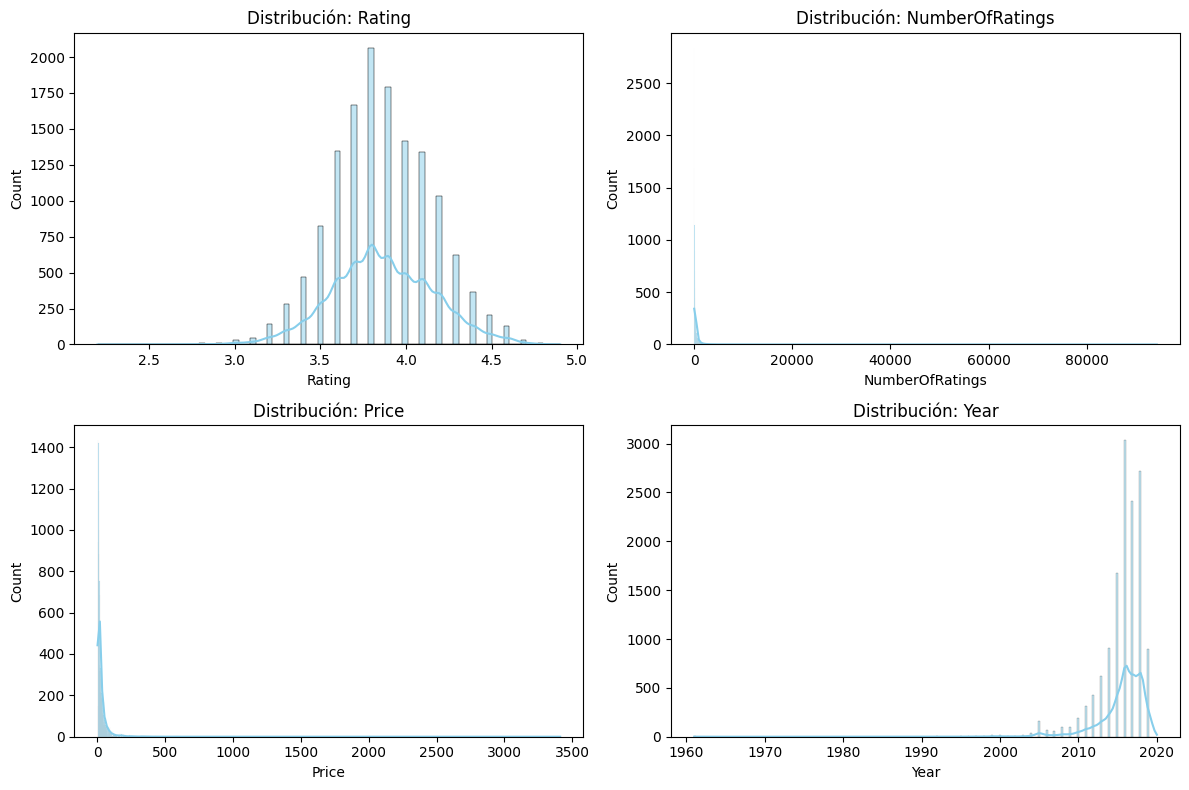

In [191]:
# Gráfico de distribución

# Lista de columnas numéricas que queremos analizar
cols_numericas = ['Rating', 'NumberOfRatings', 'Price', 'Year']

# Configuración del tamaño de la figura (ancho, alto)
plt.figure(figsize=(12, 8))

# Recorremos cada columna numérica
for i, col in enumerate(cols_numericas, 1):

    # Creamos una grilla de 2 filas y 2 columnas y ubicamos cada gráfico
    plt.subplot(2, 2, i)

    # Generamos un histograma con curva de densidad (KDE)
    # Esto permite ver la distribución de los datos y su forma
    sb.histplot(df_final[col], kde=True, color='skyblue')

    # Título dinámico según la columna analizada
    plt.title(f'Distribución: {col}')

# Ajusta automáticamente los espacios entre gráficos
plt.tight_layout()

# Muestra los gráficos en pantalla
plt.show()

* A partir del análisis de las distribuciones de las variables numéricas, se observa que el Rating presenta una distribución aproximadamente normal, con una clara concentración de valores entre 3.5 y 4.2. Esto indica que la mayoría de los vinos poseen calificaciones similares, reflejando una baja variabilidad en esta variable.

* En el caso de NumberOfRatings, se observa una fuerte asimetría positiva (sesgo hacia la derecha). La mayoría de los vinos concentra un número bajo de valoraciones, mientras que existe un pequeño grupo con valores extremadamente altos, lo que evidencia la presencia de outliers.

* La variable Price también presenta una distribución fuertemente asimétrica positiva. Se aprecia que la mayoría de los vinos tiene precios bajos, mientras que algunos pocos alcanzan valores muy elevados, generando una cola larga hacia la derecha. Esto sugiere una alta dispersión y presencia de valores atípicos.

* El gráfico de Year muestra una concentración en años recientes, principalmente posterior al 2010. Esto indica que el dataset está compuesto mayoritariamente por vinos modernos, con menor presencia de registros antiguos.

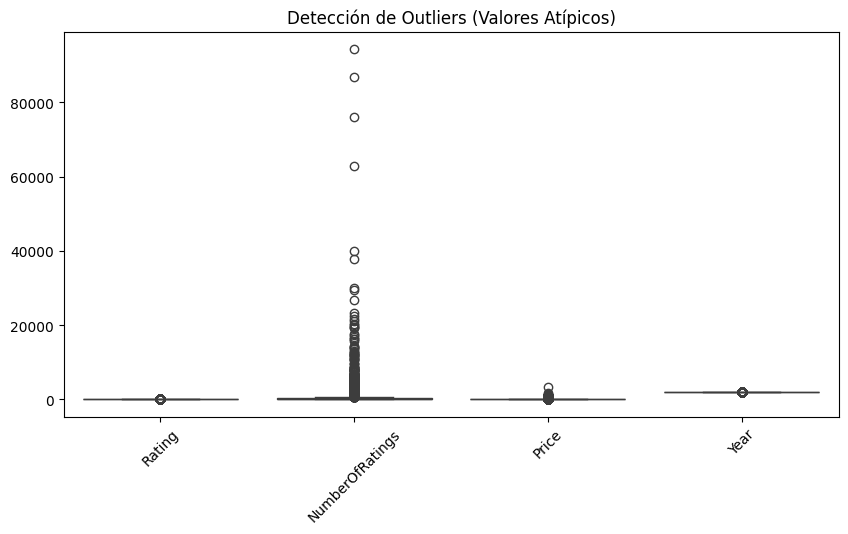

In [192]:
# Boxplot para detectar Outliers

# Configuración del tamaño de la figura
plt.figure(figsize=(10, 5))

# Creamos el boxplot para todas las variables numéricas seleccionadas
# Permite identificar valores atípicos (outliers)
sb.boxplot(data=df_final[['Rating', 'NumberOfRatings', 'Price', 'Year']])

# Rotamos las etiquetas del eje X para mejor visualización
plt.xticks(rotation=45)

# Título del gráfico
plt.title('Detección de Outliers (Valores Atípicos)')

# Muestra el gráfico en pantalla
plt.show()

* A partir del boxplot, se observa que las variables NumberOfRatings y Price presentan una gran cantidad de valores atípicos (outliers), evidenciado por los múltiples puntos que se encuentran fuera de los rangos normales. En particular, NumberOfRatings muestra una alta dispersión, con numerosos registros que superan ampliamente el rango intercuartílico, lo que indica que existen vinos con una cantidad excepcionalmente alta de valoraciones en comparación con la mayoría.

* De forma similar, la variable Price también presenta outliers, lo que sugiere la existencia de vinos con precios significativamente más elevados que el resto.

* Por otro lado, la variable Rating no presenta valores atípicos relevantes, lo que confirma su baja variabilidad. En cuanto a Year, se observa una distribución más compacta, con escasa presencia de outliers, lo que indica que los valores se encuentran relativamente concentrados.

* **Desición de los outliers:** Los valores atípicos identificados corresponden a casos reales del dominio (vinos premium o altamente valorados), por lo que no seran eliminados para evitar la pérdida de información relevante.

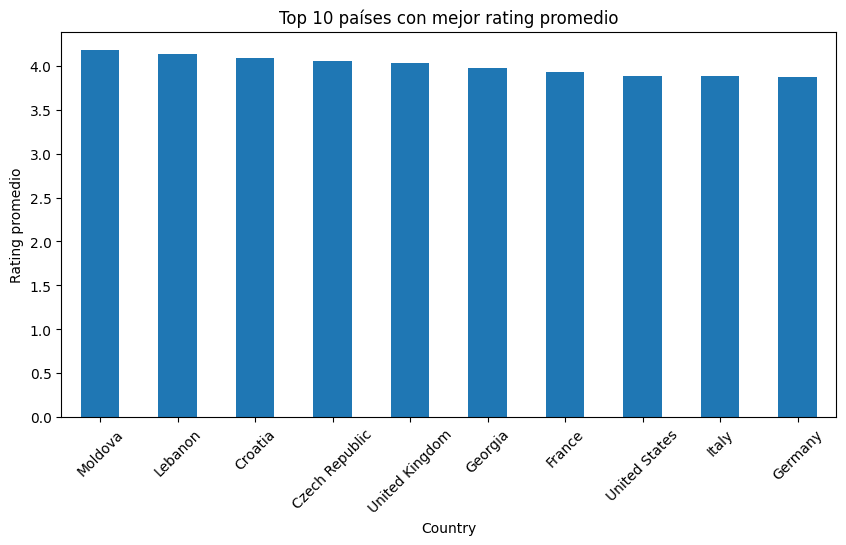

In [193]:
# Promedio de rating por país
top_countries = df_wines.groupby('Country')['Rating'].mean().sort_values(ascending=False).head(10)

# Configuración del gráfico
plt.figure(figsize=(10,5))

# Gráfico de barras con los 10 países mejor evaluados
top_countries.plot(kind='bar')

# Título y etiquetas
plt.title('Top 10 países con mejor rating promedio')
plt.ylabel('Rating promedio')

# Rotación de etiquetas para mejor visualización
plt.xticks(rotation=45)

# Mostrar gráfico
plt.show()

* A partir del gráfico se observa que los países con mejor rating promedio presentan valores muy similares, todos concentrados en torno a 4.0 y 4.2. Esto indica que, aunque existen diferencias entre países, estas no son significativamente amplias, lo que sugiere que la calidad de los vinos evaluados es relativamente homogénea a nivel internacional.

* Países como Moldova, Lebanon y Croatia lideran el ranking, aunque la diferencia con países como Germany o Italy es mínima. Esto refleja que el rating no varía drásticamente según el país, lo que puede estar influenciado por la naturaleza de la plataforma (Vivino), donde la mayoría de los vinos tienden a tener buenas valoraciones.

* En conclusión, el país de origen no parece ser un factor altamente diferenciador en términos de calificación promedio, ya que los valores se mantienen dentro de un rango bastante acotado.

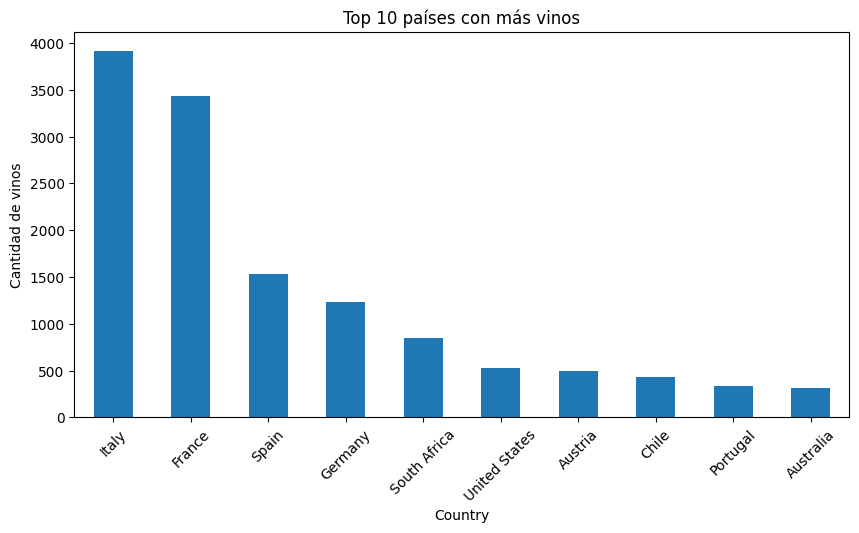

In [194]:
# Contar cantidad de vinos por país
country_count = df_wines['Country'].value_counts().head(10)

# Configuración del gráfico
plt.figure(figsize=(10,5))

# Gráfico de barras
country_count.plot(kind='bar')

# Título y etiquetas
plt.title('Top 10 países con más vinos')
plt.ylabel('Cantidad de vinos')

plt.xticks(rotation=45)

plt.show()

* A partir del gráfico se observa que Italia y Francia concentran la mayor cantidad de vinos dentro del dataset, destacándose significativamente por sobre el resto de los países. Esto indica que existe una mayor representación de estos países, lo que puede deberse a su relevancia histórica y productiva en la industria vitivinícola.

* En segundo nivel aparecen países como España y Alemania, aunque con una cantidad considerablemente menor. Posteriormente, el resto de los países presenta una participación más reducida, evidenciando una distribución desigual en la cantidad de registros.

* Esta concentración de datos en ciertos países puede influir en el análisis y en el modelamiento, ya que el modelo podría verse más influenciado por las características de los países con mayor presencia en el dataset.

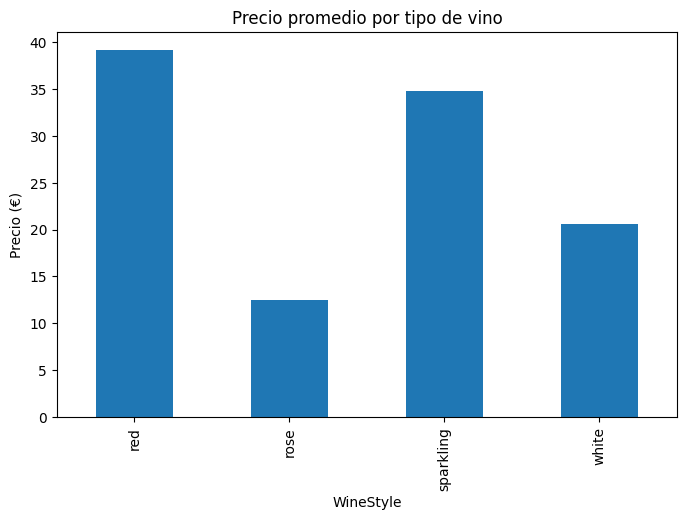

In [195]:
# Agrupar por tipo de vino y calcular precio promedio
price_by_style = df_wines.groupby('WineStyle')['Price'].mean()

# Configuración del gráfico
plt.figure(figsize=(8,5))

# Gráfico de barras
price_by_style.plot(kind='bar')

# Título y etiquetas
plt.title('Precio promedio por tipo de vino')
plt.ylabel('Precio (€)')

plt.show()

* A partir del gráfico se observa que el tipo de vino influye significativamente en el precio promedio. Los vinos red presentan el mayor precio promedio, seguidos por los vinos sparkling, lo que sugiere que estos tipos suelen posicionarse en segmentos más altos del mercado.

* Por otro lado, los vinos white presentan un precio intermedio, mientras que los vinos rose tienen el precio promedio más bajo, lo que podría indicar una menor valoración en términos comerciales o una mayor oferta en rangos económicos.

* Esta diferencia entre tipos de vino evidencia que el WineStyle es una variable relevante para explicar el precio, por lo que resulta útil considerarla en el modelamiento.

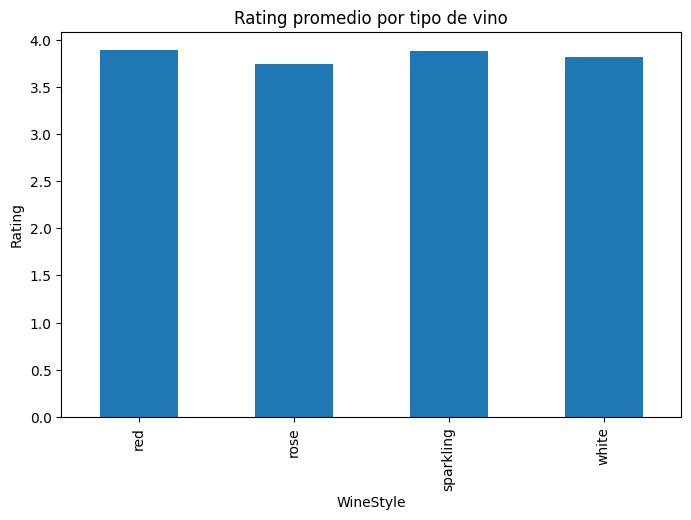

In [196]:
# Agrupar por tipo de vino y calcular rating promedio
rating_by_style = df_wines.groupby('WineStyle')['Rating'].mean()

# Configuración del gráfico
plt.figure(figsize=(8,5))

# Gráfico de barras
rating_by_style.plot(kind='bar')

# Título y etiquetas
plt.title('Rating promedio por tipo de vino')
plt.ylabel('Rating')

plt.show()

* A partir del gráfico se observa que el rating promedio es bastante similar entre los distintos tipos de vino, con valores cercanos a 3.8–3.9 en todos los casos. Esto indica que no existen diferencias significativas en la calificación según el tipo de vino.

* Los vinos red y sparkling presentan levemente mejores evaluaciones, mientras que los rose tienen un rating ligeramente inferior. Sin embargo, estas diferencias son mínimas, lo que sugiere una valoración bastante homogénea entre categorías.

* En consecuencia, el tipo de vino no parece ser un factor determinante en la calificación, a diferencia de lo observado en el precio, donde sí existían diferencias más marcadas.

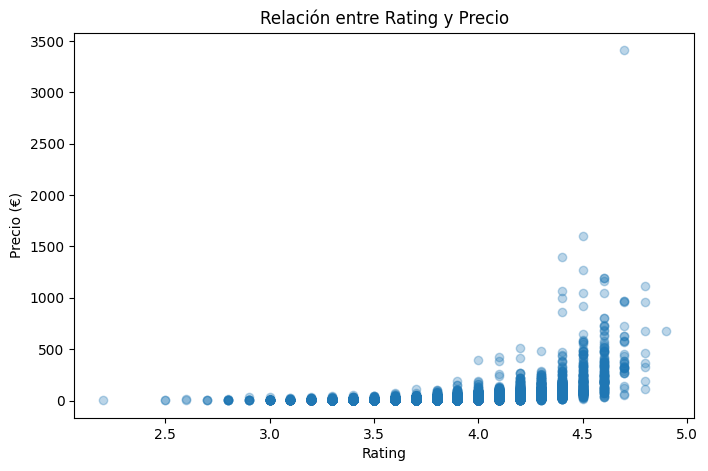

In [197]:
# Configuración del gráfico
plt.figure(figsize=(8,5))

# Scatter plot (relación entre variables)
plt.scatter(df_wines['Rating'], df_wines['Price'], alpha=0.3)

# Etiquetas y título
plt.xlabel('Rating')
plt.ylabel('Precio (€)')
plt.title('Relación entre Rating y Precio')

plt.show()

* A partir del gráfico de dispersión se observa que existe una tendencia positiva entre el rating y el precio, es decir, a medida que aumenta la calificación del vino, también tiende a aumentar su precio.

* Sin embargo, esta relación no es completamente lineal ni fuerte, ya que se aprecia una alta dispersión de los datos, especialmente en valores de rating altos (sobre 4.0), donde existen vinos con precios muy distintos.

* Además, se identifican valores atípicos, con algunos vinos que presentan precios extremadamente elevados en comparación con el resto, incluso con ratings similares.

* En conclusión, si bien el rating influye en el precio, no es el único factor determinante, lo que sugiere que existen otras variables que también afectan el valor de los vinos.

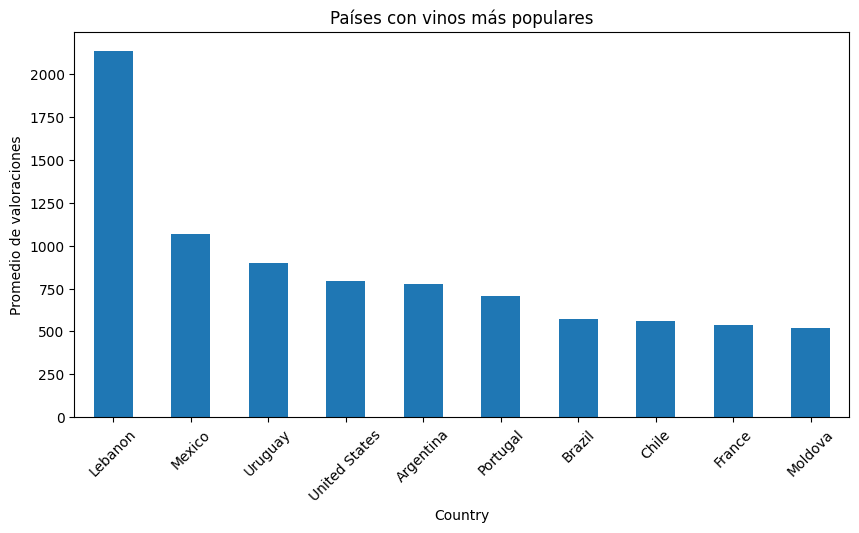

In [198]:
# Promedio de cantidad de valoraciones por país
top_popular = df_wines.groupby('Country')['NumberOfRatings'].mean().sort_values(ascending=False).head(10)

# Configuración del gráfico
plt.figure(figsize=(10,5))

# Gráfico de barras
top_popular.plot(kind='bar')

# Título y etiquetas
plt.title('Países con vinos más populares')
plt.ylabel('Promedio de valoraciones')

plt.xticks(rotation=45)

plt.show()

* A partir del gráfico se observa que algunos países presentan un mayor promedio de valoraciones (NumberOfRatings), lo que indica que sus vinos son más populares o tienen mayor visibilidad dentro de la plataforma.

* Destaca especialmente Lebanon, con una diferencia considerable respecto al resto, lo que sugiere la presencia de uno o pocos vinos altamente valorados que elevan el promedio. Le siguen países como Mexico y Uruguay, aunque con valores más moderados.

* En general, se observa una distribución desigual en la popularidad, donde ciertos países concentran un mayor nivel de interacción por parte de los usuarios, mientras que otros presentan menor cantidad de valoraciones promedio.

* Este comportamiento puede estar influenciado por factores como la oferta disponible, la visibilidad en la plataforma o la presencia de vinos destacados.

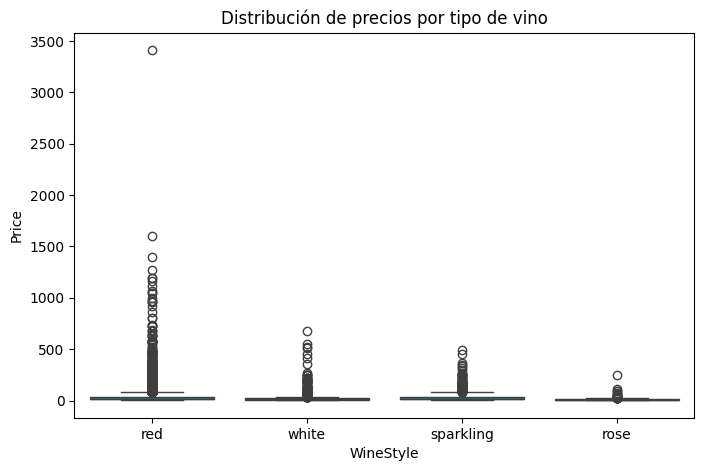

In [199]:
# Configuración del gráfico
plt.figure(figsize=(8,5))

# Boxplot para comparar precios según tipo de vino
sb.boxplot(data=df_wines, x='WineStyle', y='Price')

# Título
plt.title('Distribución de precios por tipo de vino')

plt.show()

* A partir del boxplot se observa que el precio de los vinos presenta una alta variabilidad en todos los tipos, especialmente en los vinos red, los cuales muestran la mayor dispersión y la presencia de los valores más extremos (outliers). Esto indica que dentro de esta categoría existen vinos significativamente más caros que el resto.

* Los vinos sparkling y white también presentan outliers, aunque en menor magnitud, mientras que los vinos rose muestran una distribución más compacta y con precios generalmente más bajos.

* En general, se aprecia que la mayoría de los precios se concentra en rangos bajos para todos los tipos de vino, pero con una cola larga hacia valores altos, lo que confirma una distribución asimétrica positiva.

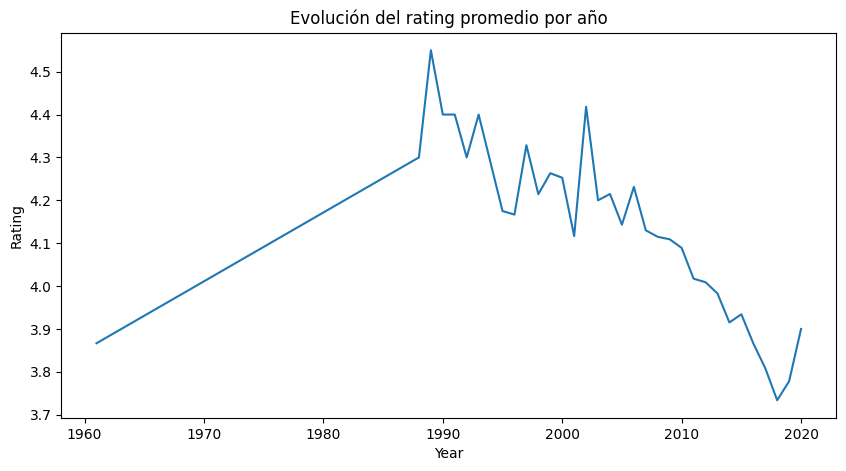

In [200]:
# Promedio de rating por año
rating_year = df_wines.groupby('Year')['Rating'].mean()

# Configuración del gráfico
plt.figure(figsize=(10,5))

# Gráfico de línea
rating_year.plot()

# Título y etiquetas
plt.title('Evolución del rating promedio por año')
plt.ylabel('Rating')

plt.show()

* A partir del gráfico se observa que el rating promedio de los vinos presenta una tendencia variable a lo largo del tiempo. En una primera etapa, se aprecia un aumento progresivo hasta alcanzar valores cercanos a 4.5 alrededor de finales de los años 80 y principios de los 90.

* Posteriormente, el rating muestra fluctuaciones moderadas, manteniéndose en rangos relativamente altos (sobre 4.1), lo que indica una estabilidad en la calidad percibida de los vinos durante ese período.

* Sin embargo, en los años más recientes se observa una leve tendencia a la baja, con valores que descienden por debajo de 4.0 en algunos casos. Esto podría estar relacionado con una mayor diversidad de vinos evaluados o con cambios en el comportamiento de los usuarios al momento de calificar.

* En general, el rating se mantiene dentro de un rango acotado, lo que confirma una baja variabilidad a lo largo del tiempo.

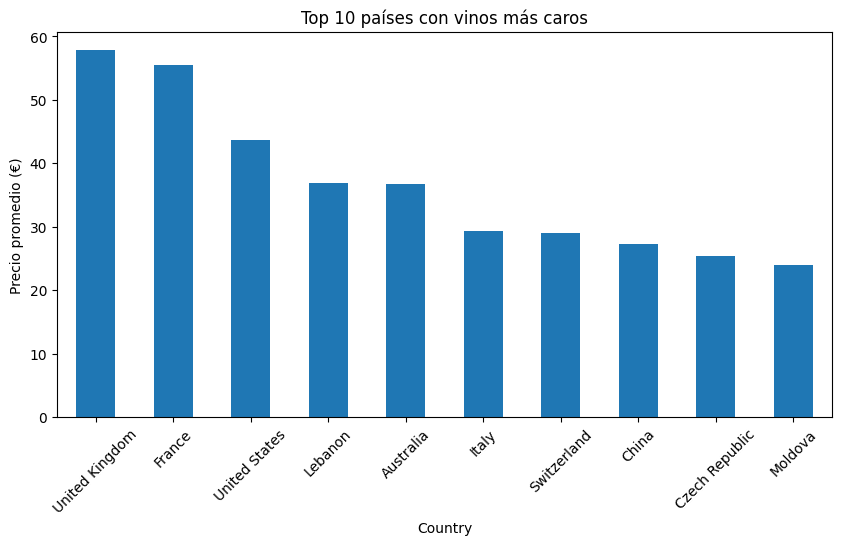

In [201]:
# Precio promedio por país
price_country = df_wines.groupby('Country')['Price'].mean().sort_values(ascending=False).head(10)

# Configuración del gráfico
plt.figure(figsize=(10,5))

# Gráfico de barras
price_country.plot(kind='bar')

# Título y etiquetas
plt.title('Top 10 países con vinos más caros')
plt.ylabel('Precio promedio (€)')

plt.xticks(rotation=45)

plt.show()

* A partir del gráfico se observa que los países con mayor precio promedio de vinos (expresado en euros) son United Kingdom y France, seguidos por United States y Lebanon. Esto indica que los vinos provenientes de estos países tienden a posicionarse en segmentos de precio más alto dentro del mercado.

* En un nivel intermedio se encuentran países como Australia e Italy, mientras que otros como China, Czech Republic y Moldova presentan precios promedio más bajos en comparación con el resto del ranking.

* Estas diferencias pueden estar asociadas a factores como la reputación del país productor, la calidad percibida, la demanda del mercado o la presencia de vinos premium dentro del dataset.

* En general, se evidencia que el país de origen influye en el precio del vino, aunque no necesariamente de forma directa con el rating, como se observó en análisis anteriores.

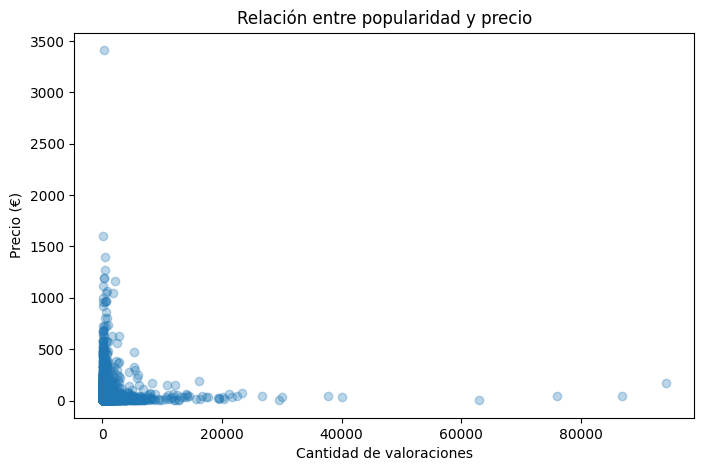

In [202]:
# Relación entre Popularidad y Precio
# Configuración del tamaño del gráfico
plt.figure(figsize=(8,5))

# Scatter plot: relación entre cantidad de valoraciones y precio
plt.scatter(df_wines['NumberOfRatings'], df_wines['Price'], alpha=0.3)

# Etiquetas de los ejes
plt.xlabel('Cantidad de valoraciones')
plt.ylabel('Precio (€)')

# Título del gráfico
plt.title('Relación entre popularidad y precio')

# Mostrar gráfico
plt.show()

* A partir del gráfico de dispersión se observa que no existe una relación directa entre la cantidad de valoraciones (NumberOfRatings) y el precio del vino. La mayoría de los vinos con alta popularidad se concentran en rangos de precio bajos, lo que sugiere que los vinos más accesibles tienden a recibir más valoraciones por parte de los usuarios.

* Además, se identifican algunos valores atípicos, como vinos con precios extremadamente altos pero con pocas valoraciones, lo que indica que los vinos más caros no necesariamente son los más populares.

* En general, se aprecia una alta dispersión en los datos, lo que refuerza la idea de que la popularidad no depende del precio, sino de otros factores como disponibilidad, preferencia del consumidor o visibilidad en la plataforma.

# **Estandarización a las variables numéricas**

In [203]:
# Separamos variables independientes (X) y variable objetivo (y)
X = df_final.drop(columns=['Price'])
y = df_final['Price']

# Definimos SOLO las columnas numéricas de X (sin Price)
cols_a_escalar = ['Rating', 'NumberOfRatings', 'Year']

# Inicializamos el escalador
scaler = StandardScaler()

# Aplicamos el escalado SOLO a X
X[cols_a_escalar] = scaler.fit_transform(X[cols_a_escalar])

# Verificamos
print(X[cols_a_escalar].head())

     Rating  NumberOfRatings      Year
0  1.127927        -0.178597 -1.429066
1  1.465290        -0.178597  0.452538
2  0.115836        -0.178597 -0.174663
3 -1.233618        -0.178597  1.079739
4  0.115836        -0.178597  0.138937


* Se aplicó una estandarización a las variables numéricas independientes utilizando la técnica StandardScaler, con el objetivo de normalizar los datos y evitar que variables con mayor magnitud influyan de forma desproporcionada en el modelo.

* Para ello, se realizó la separación entre las variables independientes (X) y la variable objetivo (y), donde X contiene las características del vino y y corresponde al precio (Price), que es la variable que se desea predecir. No escale el precio debido a que es la variable objetivo que el modelo debe predecir, y necesito que los resultados se mantengan en valores reales (euros) para que sean interpretables.

* Este proceso permite que dichas variables tengan una media cercana a 0 y una desviación estándar igual a 1, mejorando así el rendimiento de los algoritmos de machine learning.

* Cabe destacar que la variable objetivo (Price) no fue transformada, con el fin de mantener su interpretabilidad en valores reales.

# **Correlación**

In [204]:
# Creamos una copia de X (variables independientes ya procesadas/escaladas)
# Esto lo hacemos para no modificar el dataset original
df_corr = X.copy()

# Agregamos la variable objetivo (Price) al dataframe de correlación
# Esto es clave porque queremos ver cómo se relaciona Price con las demás variables
df_corr['Price'] = y

# Calculamos la matriz de correlación
# .corr() mide la relación lineal entre todas las variables numéricas
# Los valores van entre -1 y 1:
#  1  → correlación positiva fuerte
# -1 → correlación negativa fuerte
#  0 → no hay relación
corr_matrix = df_corr.corr()

# Mostramos la matriz de correlación completa
corr_matrix

,Rating,NumberOfRatings,Year,Country_Argentina,Country_Australia,Country_Austria,Country_Brazil,Country_Bulgaria,Country_Canada,Country_Chile,Country_China,Country_Croatia,Country_Czech Republic,Country_France,Country_Georgia,Country_Germany,Country_Greece,Country_Hungary,Country_Israel,Country_Italy,Country_Lebanon,Country_Luxembourg,Country_Mexico,Country_Moldova,Country_New Zealand,Country_Portugal,Country_Romania,Country_Slovakia,Country_Slovenia,Country_South Africa,Country_Spain,Country_Switzerland,Country_Turkey,Country_United Kingdom,Country_United States,Country_Uruguay,WineStyle_red,WineStyle_rose,WineStyle_sparkling,WineStyle_white,Price
Rating,1.000000,0.065520,-0.335230,-0.025991,-0.040163,-0.032401,-0.072266,-0.002664,-0.021481,-0.085905,-0.033074,0.015296,0.007478,0.130254,0.011512,0.002227,-0.026077,-0.023361,-0.016223,0.030882,0.031206,-0.004750,-0.013357,0.035511,-0.008165,-0.001843,-0.022804,-0.004692,-0.024909,-0.054604,-0.066395,-0.005449,-0.018661,0.008331,0.015243,-0.005495,0.107806,-0.072111,0.014339,-0.098504,0.450654
NumberOfRatings,0.065520,1.000000,-0.022741,0.028801,-0.006771,-0.032259,0.004735,0.000135,-0.002625,0.012709,-0.001965,-0.003818,-0.002144,0.033815,-0.005098,-0.055572,-0.005179,-0.006652,-0.005760,-0.010938,0.031592,-0.001736,0.002949,0.001687,-0.001101,0.023668,-0.008808,-0.002481,-0.005415,-0.027584,0.009059,-0.007819,-0.005095,-0.002013,0.039690,0.004883,-0.009182,-0.015577,0.164265,-0.080068,0.021794
Year,-0.335230,-0.022741,1.000000,0.051387,0.024185,0.062789,-0.047539,-0.000215,0.003586,0.047357,0.006665,0.005072,0.007327,-0.216878,-0.002397,0.089277,-0.002094,0.005765,0.023475,0.033066,-0.103985,0.005135,-0.006818,0.014732,0.050555,0.010582,0.006317,0.001671,0.006273,0.090237,-0.020858,0.019024,0.007954,-0.005651,0.015449,0.007412,-0.299467,0.140922,-0.057316,0.306114,-0.377850
Country_Argentina,-0.025991,0.028801,0.051387,1.000000,-0.023146,-0.028978,-0.009088,-0.001815,-0.002222,-0.027060,-0.002222,-0.003143,-0.001815,-0.086745,-0.004628,-0.047119,-0.006421,-0.005596,-0.006158,-0.094871,-0.005135,-0.004803,-0.001283,-0.005135,-0.016579,-0.023808,-0.007814,-0.001815,-0.005447,-0.038513,-0.053271,-0.006158,-0.004059,-0.002222,-0.030119,-0.002869,0.053739,-0.008331,-0.042281,-0.030607,-0.025767
Country_Australia,-0.040163,-0.006771,0.024185,-0.023146,1.000000,-0.029455,-0.009238,-0.001844,-0.002259,-0.027506,-0.002259,-0.003195,-0.001844,-0.088174,-0.004704,-0.047895,-0.006526,-0.005688,-0.006260,-0.096434,-0.005219,-0.004882,-0.001304,-0.005219,-0.016852,-0.024201,-0.007943,-0.001844,-0.005536,-0.039147,-0.054149,-0.006260,-0.004125,-0.002259,-0.030615,-0.002917,0.046660,-0.026365,-0.033694,-0.021160,0.008127
Country_Austria,-0.032401,-0.032259,0.062789,-0.028978,-0.029455,1.000000,-0.011566,-0.002309,-0.002828,-0.034436,-0.002828,-0.004000,-0.002309,-0.110388,-0.005889,-0.059962,-0.008171,-0.007122,-0.007837,-0.120729,-0.006534,-0.006112,-0.001633,-0.006534,-0.021098,-0.030298,-0.009944,-0.002309,-0.006931,-0.049010,-0.067791,-0.007837,-0.005165,-0.002828,-0.038328,-0.003651,-0.071165,-0.009630,-0.025260,0.095715,-0.034180
Country_Brazil,-0.072266,0.004735,-0.047539,-0.009088,-0.009238,-0.011566,1.000000,-0.000724,-0.000887,-0.010800,-0.000887,-0.001255,-0.000724,-0.034622,-0.001847,-0.018806,-0.002563,-0.002234,-0.002458,-0.037865,-0.002049,-0.001917,-0.000512,-0.002049,-0.006617,-0.009502,-0.003119,-0.000724,-0.002174,-0.015371,-0.021262,-0.002458,-0.001620,-0.000887,-0.012021,-0.001145,0.021610,-0.010352,0.001671,-0.020582,-0.013274
Country_Bulgaria,-0.002664,0.000135,-0.000215,-0.001815,-0.001844,-0.002309,-0.000724,1.000000,-0.000177,-0.002156,-0.000177,-0.000250,-0.000145,-0.006912,-0.000369,-0.003755,-0.000512,-0.000446,-0.000491,-0.007560,-0.000409,-0.000383,-0.000102,-0.000409,-0.001321,-0.001897,-0.000623,-0.000145,-0.000434,-0.003069,-0.004245,-0.000491,-0.000323,-0.000177,-0.002400,-0.000229,0.009286,-0.002067,-0.003369,-0.007352,-0.003880
Country_Canada,-0.021481,-0

* Se construyó una matriz de correlación con el objetivo de analizar la relación lineal entre las variables numéricas del dataset, especialmente aquellas que podrían influir en el precio del vino (Price).

* La correlación permite identificar el grado de relación entre variables, tomando valores entre -1 y 1, donde valores cercanos a 1 indican una relación positiva fuerte, valores cercanos a -1 una relación negativa fuerte y valores cercanos a 0 indican ausencia de relación lineal.

* Este análisis resulta clave para identificar qué variables tienen mayor impacto sobre el precio y, por tanto, cuáles son más relevantes para el modelamiento predictivo.

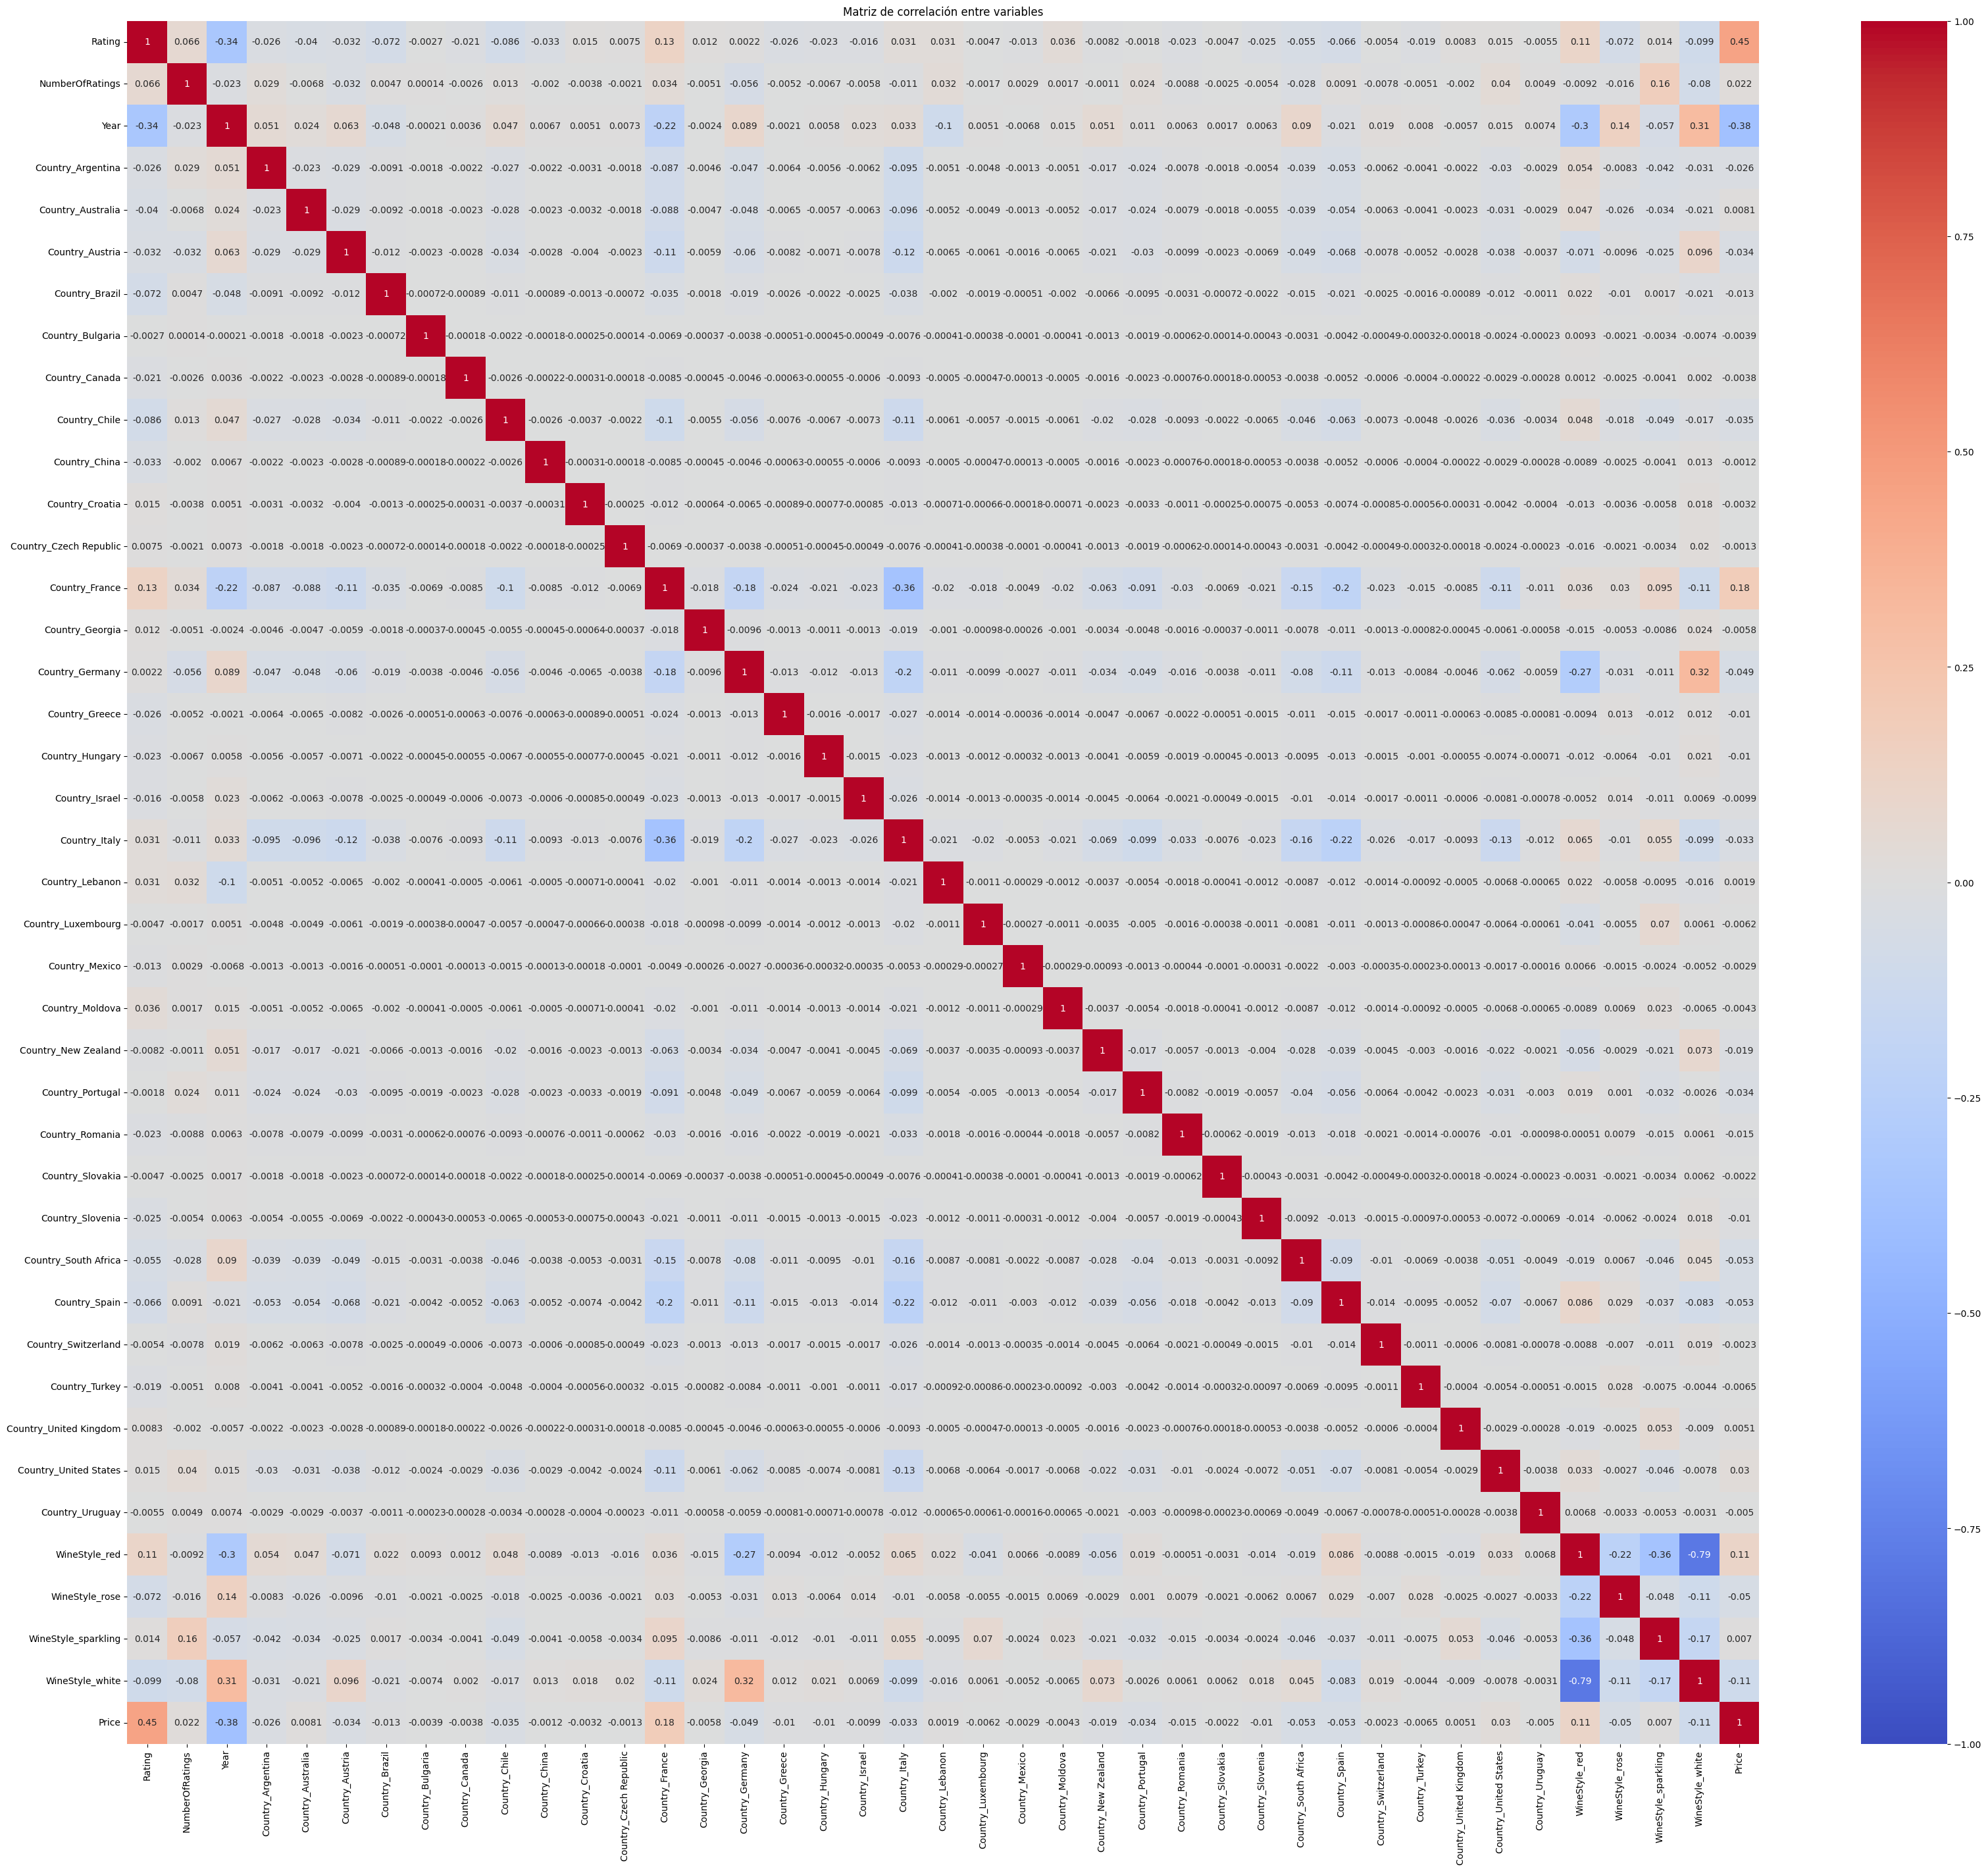

In [205]:
# Creamos un dataframe para la correlación
# Usamos una copia de X (variables independientes ya procesadas)
df_corr = X.copy()

# Agregamos la variable objetivo (Price) al dataframe
# Esto permite analizar la relación entre el precio y las demás variables
df_corr['Price'] = y

# Calculamos la matriz de correlación
corr_matrix = df_corr.corr()

# Configuramos el tamaño del gráfico
# Se define un tamaño grande para visualizar correctamente todas las variables
plt.figure(figsize=(40, 34))

# Creamos el heatmap (mapa de calor) de la correlación
# vmin y vmax fijan el rango de colores entre -1 y 1
# annot=True muestra los valores numéricos en cada celda
# cmap="coolwarm" usa una escala de colores (rojo = positivo, azul = negativo)
sb.heatmap(
    corr_matrix,
    vmin=-1,
    vmax=+1,
    annot=True,
    cmap="coolwarm"
)

# Título del gráfico
plt.title("Matriz de correlación entre variables")

# Mostramos el gráfico
plt.show()

* Se observa una correlación positiva moderada (0.45) entre la variable Rating y el Price, lo que indica que, en general, a medida que aumenta la calificación de un vino, su precio tiende a incrementarse. Sin embargo, al no tratarse de una correlación fuerte, se concluye que el Rating no es el único factor que determina el precio, existiendo otras variables que también influyen en su valor.

* Se observa una correlación positiva baja (0.31) entre la variable Year y WineStyle_white, lo que indica que los vinos blancos tienden, en cierta medida, a ser de años más recientes en comparación con otros tipos de vino. No obstante, al tratarse de una correlación baja, esta relación no es concluyente, sino que refleja únicamente una tendencia dentro del conjunto de datos.

* Se observa una correlación positiva baja (0.32) entre la variable Country_Germany y WineStyle_white, lo que indica que los vinos provenientes de Alemania tienden, en cierta medida, a ser de tipo blanco. Sin embargo, al tratarse de una correlación baja, esta relación no es determinante, aunque sí sugiere una tendencia dentro del dataset.

* Se observa una correlación positiva baja (0.18) entre la variable Price y la categoría Country_France, lo que indica que los vinos provenientes de Francia tienden, en cierta medida, a presentar precios ligeramente más altos en comparación con otros países. Sin embargo, debido a que la correlación es débil, esta relación no es determinante, sino que representa únicamente una leve tendencia dentro del conjunto de datos. Esto sugiere que, si bien el origen geográfico puede influir en el precio, existen otros factores más relevantes que explican su variación.

* Se observa una correlación negativa fuerte (-0.79) entre las variables WineStyle_red y WineStyle_white, lo que indica que ambas categorías son prácticamente excluyentes dentro del dataset. Esto se debe a que un vino no puede ser simultáneamente tinto y blanco, por lo que cuando una de estas variables toma el valor 1, la otra tiende a tomar el valor 0. Esta relación inversa es coherente con la naturaleza de las variables categóricas codificadas mediante One-Hot Encoding y no representa una relación causal, sino una característica propia de la transformación de los datos.

In [206]:
#----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# **5. Modelado**



El presente proyecto corresponde a un problema de regresión múltiple, ya que la variable objetivo corresponde a Price, un valor numérico continuo expresado en euros (€). El objetivo principal es predecir el precio de un vino a partir de distintas características disponibles en el dataset.

Para el entrenamiento de los modelos se utilizaron las siguientes variables predictoras:

* Rating
* NumberOfRatings
* Year
* Country, codificada mediante One-Hot Encoding
* WineStyle, codificada mediante One-Hot Encoding

La variable objetivo utilizada fue:

* Price

Con el propósito de comparar distintos enfoques de predicción, se aplicaron tres modelos de regresión: Regresión Lineal, Árbol de Decisión y Random Forest Regressor.


---



**Modelado 1: Regresión Lineal**

El primer modelo utilizado fue la Regresión Lineal, debido a su capacidad para estimar la relación entre un conjunto de variables independientes y una variable objetivo numérica.

Este modelo busca identificar cómo las características de los vinos influyen en el precio final, asumiendo una relación lineal entre las variables de entrada y el valor de Price.

Se seleccionó este algoritmo porque permite interpretar de manera sencilla el efecto de las variables sobre el precio del vino. Además, funciona como un buen modelo base para evaluar el comportamiento inicial de los datos y comparar posteriormente su desempeño con modelos más complejos.


---



**Modelado 2: Árbol de Decisión para regresión**

El segundo modelo utilizado corresponde a un Árbol de Decisión para regresión o DecisionTreeRegressor.

Este algoritmo divide los datos en distintas ramas según las características de los vinos, generando reglas de decisión que buscan minimizar el error en la predicción del precio.

A diferencia de la Regresión Lineal, el Árbol de Decisión permite capturar relaciones no lineales entre las variables, por lo que puede adaptarse mejor a patrones más complejos presentes en el dataset.

Este modelo fue seleccionado por su capacidad para representar relaciones más flexibles entre las variables predictoras y el precio del vino.


---



**Modelado 3: Random Forest Regressor**

El tercer modelo utilizado fue Random Forest Regressor, un algoritmo basado en la combinación de múltiples árboles de decisión.

A diferencia de un Árbol de Decisión individual, Random Forest entrena varios árboles sobre distintas muestras del dataset y combina sus predicciones para obtener un resultado más robusto. Esto permite reducir el riesgo de sobreajuste y mejorar la estabilidad del modelo.

Este enfoque resulta útil en problemas de regresión con mayor complejidad, ya que puede capturar relaciones no lineales, manejar mejor la variabilidad de los datos y entregar predicciones más consistentes.

Se seleccionó este modelo debido a su capacidad para mejorar la precisión predictiva en comparación con modelos individuales, especialmente cuando existen patrones complejos en los datos.

In [207]:
# Importamos librerías necesarias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos el modelo de Árbol de Decisión
from sklearn.tree import DecisionTreeRegressor


# **6. Entrenamiento y Evaluación**

#**Modelado 1:** Regresión Lineal

In [208]:
# Variables independientes
X = df_final.drop(columns=['Price'])

# Variable objetivo con transformación logarítmica
y = np.log1p(df_final['Price'])

# Dividimos el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=100
)

# Creamos el modelo de Regresión Lineal
lr = LinearRegression()

# Entrenamos el modelo
lr.fit(X_train, y_train)

# Predicción en escala logarítmica
y_pred_log = lr.predict(X_test)

# Volvemos las predicciones a escala original de precio
y_pred = np.expm1(y_pred_log)

# Volvemos y_test también a escala original
y_test_original = np.expm1(y_test)

# Evitamos precios negativos
y_pred = np.maximum(y_pred, 0)

* Se aplicó un modelo de Regresión Lineal para predecir el precio del vino utilizando como variables independientes las características disponibles del dataset. La variable objetivo (Price) fue transformada mediante log1p para reducir el efecto de precios extremos y mejorar el ajuste del modelo. Luego, el dataset se dividió en un 80% para entrenamiento y un 20% para prueba. Posteriormente, las predicciones fueron devueltas a su escala original en euros mediante expm1, permitiendo comparar el precio real con el precio estimado.

In [209]:
# Calculamos el Error Absoluto Medio (MAE)
# Indica cuánto se equivoca el modelo en promedio
mae = mean_absolute_error(y_test_original, y_pred)

# Calculamos el Error Cuadrático Medio (MSE)
# Penaliza más los errores grandes
mse = mean_squared_error(y_test_original, y_pred)

# Calculamos la Raíz del Error Cuadrático Medio(MSE) (RMSE)
# Representa el error promedio en la misma escala del precio (€)
rmse = np.sqrt(mse)

# Calculamos el coeficiente de determinación (R²)
# Mide qué porcentaje de la variabilidad del precio explica el modelo
r2 = r2_score(y_test_original, y_pred)

# Mostramos los resultados obtenidos
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 15.294587527745708
MSE: 3167.8134729698545
RMSE: 56.28333210613827
R2: 0.3928450160734641


* El modelo de Regresión Lineal obtuvo un MAE de aproximadamente 15,29€, lo que indica que las predicciones presentan un error promedio cercano a ese valor respecto al precio real. El RMSE fue de 56,28€, evidenciando la existencia de errores más grandes asociados principalmente a vinos con precios extremos. Por otro lado, el R² obtenido fue de 0,39, lo que significa que el modelo logra explicar cerca del 39% de la variabilidad del precio de los vinos. En general, el modelo presenta un desempeño moderado y puede utilizarse como una aproximación inicial para la predicción de precios.

In [210]:
# Comparamos precios reales y predichos
comparacion = pd.DataFrame({
    'Precio real': y_test_original,
    'Precio predicho': y_pred
})

comparacion.head(10)

,Precio real,Precio predicho
1206,25.02,15.378368
6016,25.12,27.194779
3867,11.19,9.673970
11382,27.50,27.071250
3603,8.40,5.291191
379,39.90,33.334415
11757,7.36,21.014938
7679,57.72,26.041270
9818,9.99,5.893638
5638,131.60,47.791323


* Al comparar los precios reales con los precios predichos, se observa que el modelo logra aproximarse bien en algunos casos, especialmente en vinos con precios medios, como los registros cercanos a 25€ y 27€. Sin embargo, presenta mayores diferencias en vinos con precios más altos o atípicos, como el caso del vino de 131,60€, donde el modelo predice un valor mucho menor. Esto indica que la Regresión Lineal funciona como una aproximación inicial, pero tiene limitaciones para capturar valores extremos del precio.

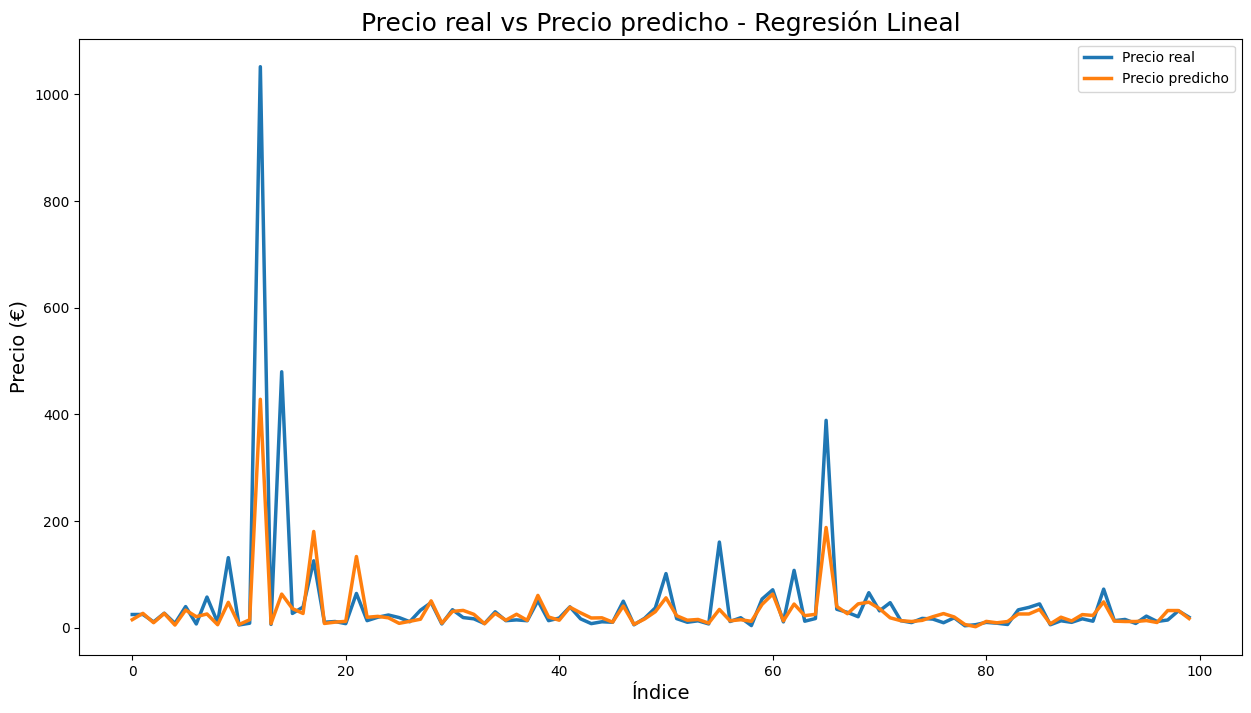

In [211]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 8))

# Cantidad de registros que se mostrarán en el gráfico
cantidad = 100

# Graficamos los precios reales
plt.plot(
    range(cantidad),
    y_test_original.iloc[:cantidad],
    linewidth=2.5,
    linestyle="-",
    label="Precio real"
)

# Graficamos los precios predichos por el modelo
plt.plot(
    range(cantidad),
    y_pred[:cantidad],
    linewidth=2.5,
    linestyle="-",
    label="Precio predicho"
)

# Agregamos título y nombres a los ejes
plt.title("Precio real vs Precio predicho - Regresión Lineal", fontsize=18)
plt.xlabel("Índice", fontsize=14)
plt.ylabel("Precio (€)", fontsize=14)

# Mostramos la leyenda
plt.legend()

# Mostramos el gráfico final
plt.show()

* El gráfico permite comparar visualmente los precios reales de los vinos con los precios predichos por el modelo de Regresión Lineal. Se observa que el modelo logra seguir la tendencia general de los datos, especialmente en vinos de precios bajos y medios. Sin embargo, en valores extremos o vinos muy costosos, las diferencias entre ambas líneas aumentan considerablemente, evidenciando que el modelo tiene dificultades para predecir correctamente precios atípicos altos.

#**Modelado 2:** Árboles de Decisión

In [212]:
# Variables independientes
X = df_final.drop(columns=['Price'])

# Variable objetivo con transformación logarítmica
y = np.log1p(df_final['Price'])

# División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=100
)

# Creamos el modelo
tree = DecisionTreeRegressor(
    max_depth=10,
    random_state=100
)

# Entrenamos el modelo
tree.fit(X_train, y_train)

# Predicciones
y_pred_log = tree.predict(X_test)

# Volvemos a escala normal
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evitamos negativos
y_pred = np.maximum(y_pred, 0)

* Se implementó un modelo de Árbol de Decisión para regresión con el objetivo de predecir el precio de los vinos. El modelo fue entrenado utilizando las variables procesadas del dataset y la variable objetivo transformada mediante log1p para reducir el impacto de valores extremos. Posteriormente, las predicciones fueron transformadas nuevamente a su escala original en euros utilizando expm1.

In [213]:
# Calculamos el Error Absoluto Medio (MAE)
# Indica cuánto se equivoca el modelo en promedio
mae = mean_absolute_error(y_test_original, y_pred)

# Calculamos el Error Cuadrático Medio (MSE)
# Penaliza más los errores grandes
mse = mean_squared_error(y_test_original, y_pred)

# Calculamos la Raíz del Error Cuadrático Medio(MSE) (RMSE)
# Representa el error promedio en la misma escala del precio (€)
rmse = np.sqrt(mse)

# Calculamos el coeficiente de determinación (R²)
# Mide qué porcentaje de la variabilidad del precio explica el modelo
r2 = r2_score(y_test_original, y_pred)

# Mostramos los resultados obtenidos
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 16.39643038507426
MSE: 7067.3675785157275
RMSE: 84.06763692715364
R2: -0.3545581156057769


* El modelo Árbol de Decisión para regresión presentó el desempeño más bajo entre los modelos evaluados. Obtuvo un MAE de 16,39, lo que indica que, en promedio, sus predicciones se alejan aproximadamente 16,39 € del precio real. Además, obtuvo un R² negativo de -0,3545, lo que significa que el modelo no logró explicar correctamente la variabilidad del precio del vino. Este resultado indica que el Árbol de Decisión no generalizó bien los datos y tuvo dificultades para realizar predicciones precisas en este caso.

In [214]:
# Comparamos precios reales y predichos
comparacion = pd.DataFrame({
    'Precio real': y_test_original,
    'Precio predicho': y_pred
})

comparacion.head(10)

,Precio real,Precio predicho
1206,25.02,8.395702
6016,25.12,10.441566
3867,11.19,7.217294
11382,27.50,25.168954
3603,8.40,9.746643
379,39.90,36.929577
11757,7.36,11.756716
7679,57.72,27.731281
9818,9.99,10.851008
5638,131.60,40.676172


* Al comparar los precios reales con los precios predichos, se observa que el modelo logra acercarse en algunos casos, especialmente en valores intermedios como 27,50 €, donde predice 25,17 €, y 39,90 €, donde predice 36,93 €. Sin embargo, presenta diferencias importantes en otros registros, principalmente en vinos de precio más alto, como el caso de 131,60 €, donde el modelo predice solo 40,76 €. Esto evidencia que el modelo tiene dificultades para capturar valores extremos, por lo que funciona como una aproximación inicial, pero requiere mejoras para aumentar su capacidad predictiva.

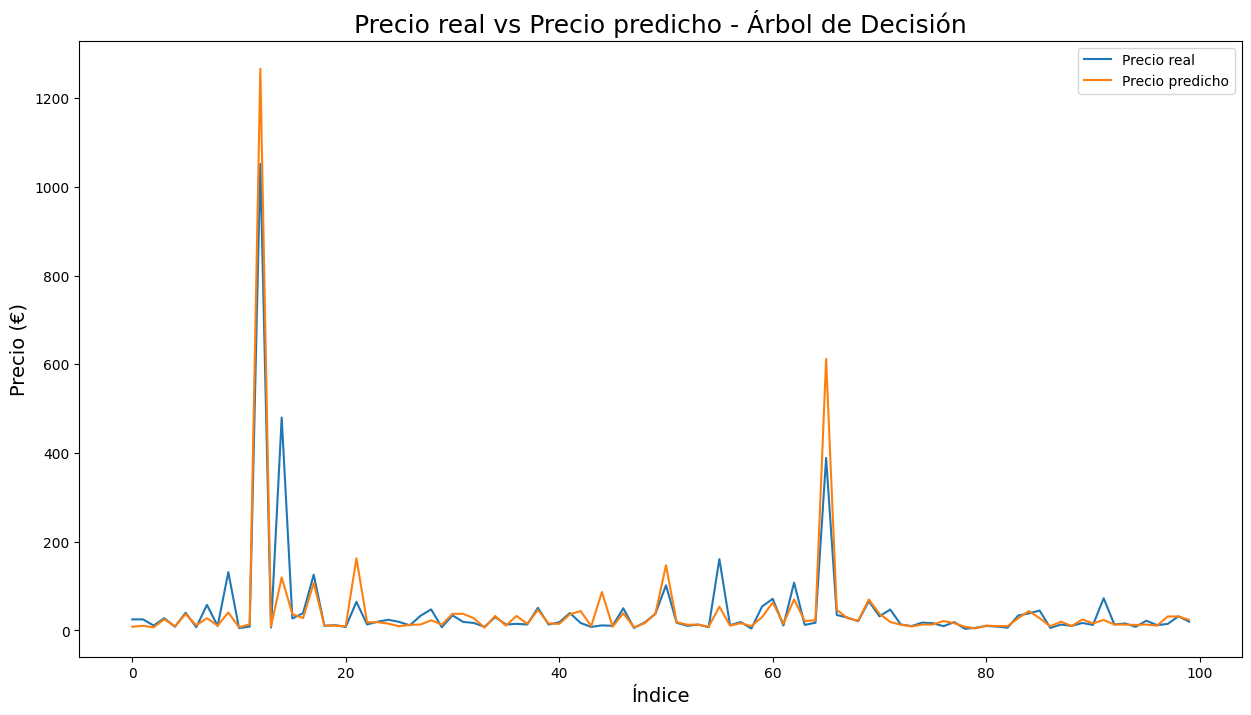

In [215]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 8))

# Cantidad de registros que se mostrarán en el gráfico
cantidad = 100

# Graficamos los precios reales
plt.plot(
    range(cantidad),
    y_test_original.iloc[:cantidad],
    label="Precio real"
)

# Graficamos los precios predichos por el modelo
plt.plot(
    range(cantidad),
    y_pred[:cantidad],
    label="Precio predicho"
)

# Agregamos título y nombres a los ejes
plt.title("Precio real vs Precio predicho - Árbol de Decisión", fontsize=18)
plt.xlabel("Índice", fontsize=14)
plt.ylabel("Precio (€)", fontsize=14)

# Mostramos la leyenda
plt.legend()

# Mostramos el gráfico final
plt.show()

* La Regresión Lineal presentó un desempeño moderado, siendo útil como modelo base debido a su simplicidad e interpretabilidad.

* Por otro lado, el Árbol de Decisión permite modelar relaciones no lineales y patrones más complejos dentro de los datos, lo que puede mejorar la precisión en ciertos casos.

* Sin embargo, este tipo de modelo también puede presentar sobreajuste si no se controlan parámetros como la profundidad del árbol (max_depth).

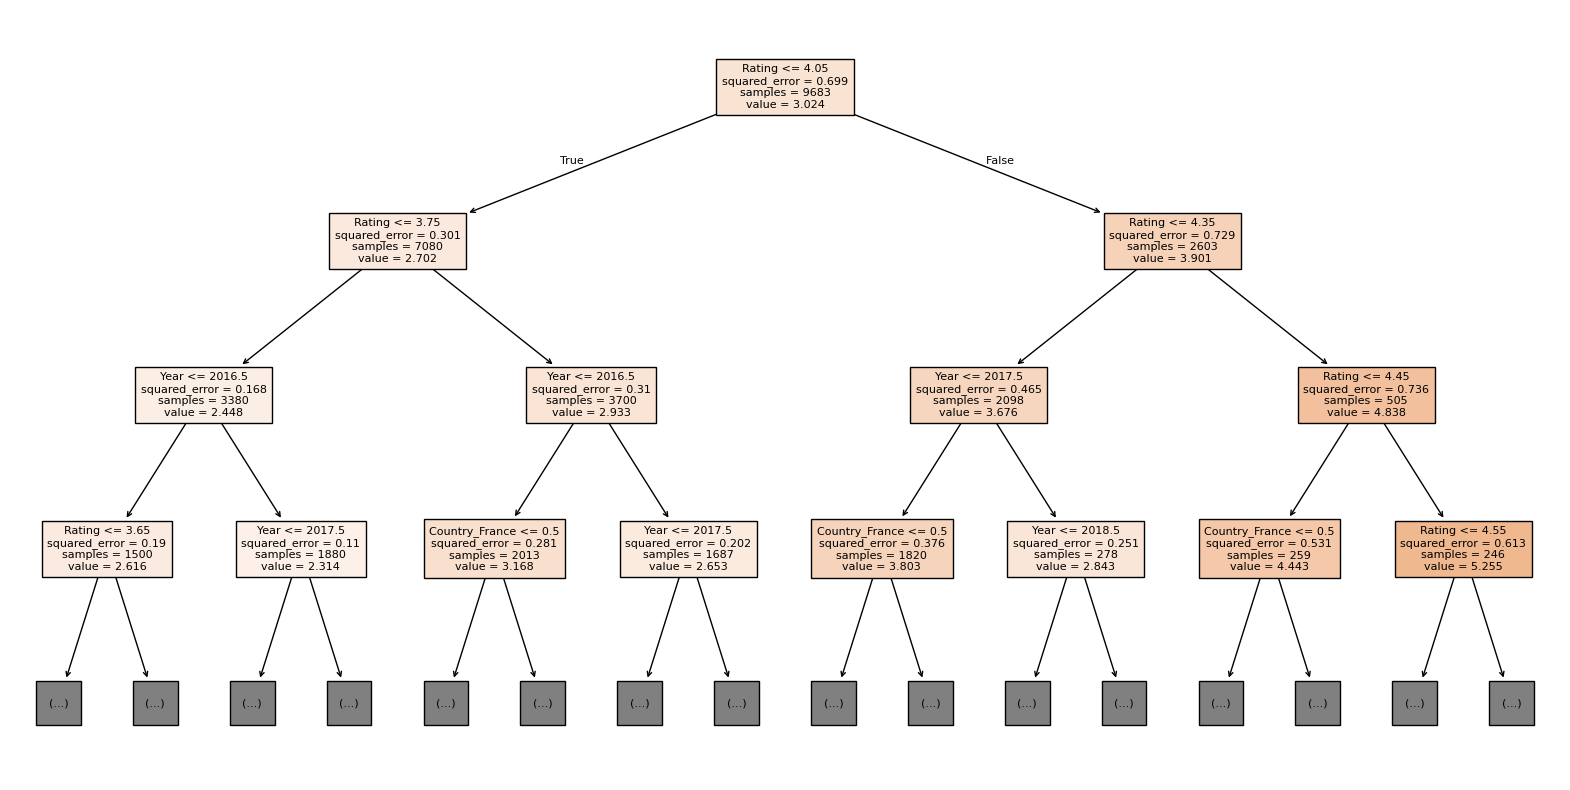

In [216]:
# Importamos la función plot_tree desde sklearn
# Esta función permite visualizar gráficamente la estructura del Árbol de Decisión
from sklearn.tree import plot_tree

# Configuramos el tamaño del gráfico
# En este caso, se define un ancho de 20 y una altura de 10 para que el árbol se vea más claro
plt.figure(figsize=(20,10))

# Graficamos el Árbol de Decisión
plot_tree(
    tree,                    # Modelo de Árbol de Decisión ya entrenado
    filled=True,             # Colorea los nodos según los valores del modelo
    max_depth=3,             # Limita la profundidad del árbol a 3 niveles para facilitar la visualización
    feature_names=X.columns, # Muestra el nombre de las variables utilizadas en el entrenamiento
    fontsize=8               # Define el tamaño de la letra dentro del gráfico
)

# Mostramos el gráfico final del Árbol de Decisión
plt.show()

* El gráfico muestra el Árbol de Decisión utilizado para predecir el precio del vino. El modelo divide los datos según condiciones como **Rating**, **Year** y **Country_France**, generando ramas que permiten estimar el valor de **Price**. La primera división se realiza por **Rating <= 4.05**, lo que indica que esta variable tiene alta importancia en la predicción. Cada nodo muestra la regla aplicada, el error, la cantidad de registros y el valor estimado. Como la variable objetivo fue transformada logarítmicamente, los valores del árbol no representan directamente euros, sino una escala transformada. En general, el árbol permite visualizar cómo el modelo toma decisiones para estimar el precio del vino.


#**Modelado 3:** Random Forest Regressor

In [217]:
# Importamos Random Forest
from sklearn.ensemble import RandomForestRegressor

# Variables independientes
X = df_final.drop(columns=['Price'])

# Variable objetivo con transformación logarítmica
y = np.log1p(df_final['Price'])

# División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.7,
    random_state=100
)

# Creamos el modelo Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=100,
    n_jobs=-1
)

# Entrenamos el modelo
rf.fit(X_train, y_train)

# Predicciones
y_pred_log = rf.predict(X_test)

# Volvemos a escala original
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Evitamos negativos
y_pred = np.maximum(y_pred, 0)

* Se implementó un modelo Random Forest Regressor utilizando múltiples árboles de decisión para predecir el precio de los vinos. La variable objetivo fue transformada mediante log1p para reducir el impacto de valores extremos y mejorar el rendimiento del modelo.

* Posteriormente, las predicciones fueron transformadas nuevamente a su escala original utilizando expm1, permitiendo interpretar los resultados en euros.

In [218]:
# Calculamos el Error Absoluto Medio (MAE)
# Indica cuánto se equivoca el modelo en promedio
mae = mean_absolute_error(y_test_original, y_pred)

# Calculamos el Error Cuadrático Medio (MSE)
# Penaliza más los errores grandes
mse = mean_squared_error(y_test_original, y_pred)

# Calculamos la Raíz del Error Cuadrático Medio(MSE) (RMSE)
# Representa el error promedio en la misma escala del precio (€)
rmse = np.sqrt(mse)

# Calculamos el coeficiente de determinación (R²)
# Mide qué porcentaje de la variabilidad del precio explica el modelo
r2 = r2_score(y_test_original, y_pred)

# Mostramos los resultados obtenidos
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 13.943249829113883
MSE: 2411.1811373320575
RMSE: 49.103779257120905
R2: 0.5378640007776925


* El modelo Random Forest Regressor presentó el mejor desempeño entre los tres modelos evaluados. Obtuvo un MAE de 13,94, lo que indica que, en promedio, sus predicciones se desvían aproximadamente 13,94 € del precio real. Además, alcanzó un R² de 0,5376, por lo que logra explicar cerca del 53,76% de la variabilidad del precio del vino. Esto demuestra que el modelo tiene una mejor capacidad predictiva, ya que combina múltiples árboles de decisión y logra capturar relaciones más complejas entre las variables.

In [219]:
# Comparamos precios reales y predichos
comparacion = pd.DataFrame({
    'Precio real': y_test_original,
    'Precio predicho': y_pred
})

comparacion.head(10)

,Precio real,Precio predicho
1206,25.02,10.675939
6016,25.12,12.921368
3867,11.19,7.560024
11382,27.50,29.220178
3603,8.40,9.478488
379,39.90,45.484094
11757,7.36,16.232060
7679,57.72,35.164924
9818,9.99,8.825704
5638,131.60,51.973509


* La tabla compara los precios reales con los precios predichos por el modelo Random Forest Regressor. Se observa que el modelo logra acercarse correctamente en algunos casos, como en el vino de 27,50 €, donde predice 29,22 €, y en el vino de 39,90 €, donde predice 45,48 €. Sin embargo, presenta diferencias importantes en valores más altos, como el caso del vino de 131,60 €, donde predice 51,97 €. Esto indica que el modelo tiene un mejor comportamiento general que los anteriores, pero aún presenta dificultades para estimar precios extremos o atípicos.

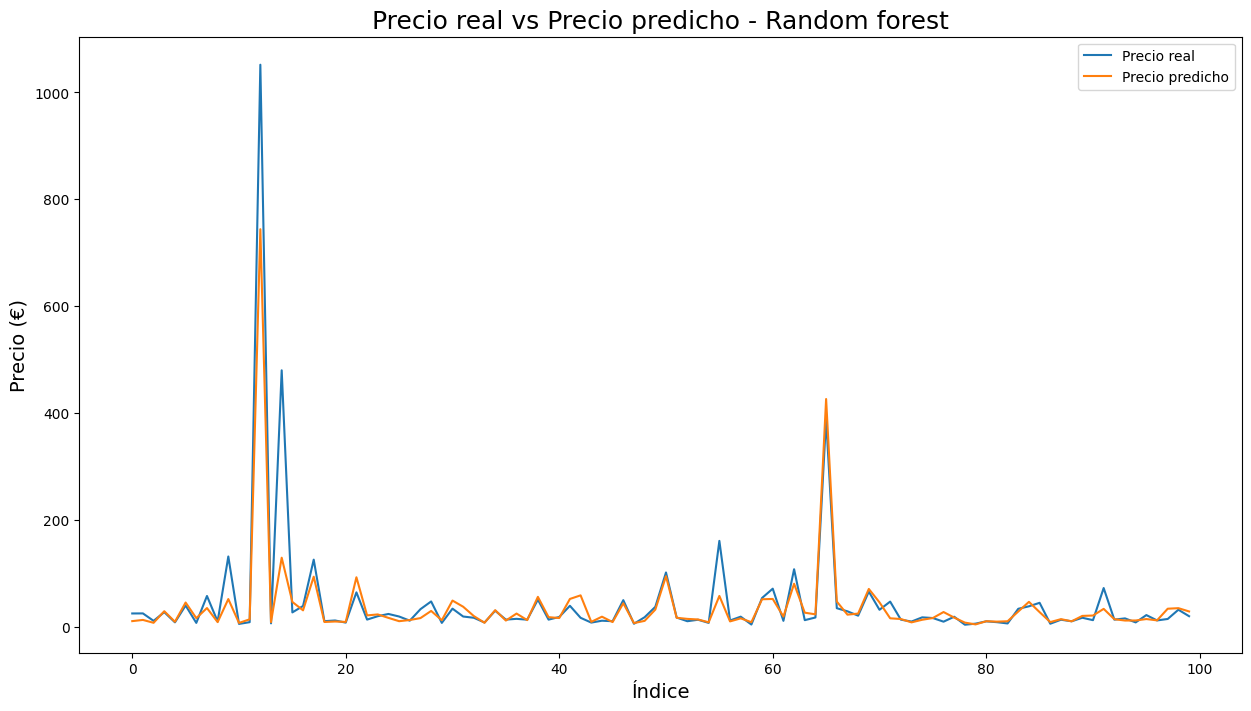

In [220]:
# Configuramos el tamaño del gráfico
plt.figure(figsize=(15, 8))

# Cantidad de registros que se mostrarán en el gráfico
cantidad = 100

# Graficamos los precios reales
plt.plot(
    range(cantidad),
    y_test_original.iloc[:cantidad],
    label="Precio real"
)

# Graficamos los precios predichos por el modelo
plt.plot(
    range(cantidad),
    y_pred[:cantidad],
    label="Precio predicho"
)

# Agregamos título y nombres a los ejes
plt.title("Precio real vs Precio predicho - Random forest", fontsize=18)
plt.xlabel("Índice", fontsize=14)
plt.ylabel("Precio (€)", fontsize=14)

# Mostramos la leyenda
plt.legend()

# Mostramos el gráfico final
plt.show()

* El gráfico compara los precios reales con los precios predichos por el modelo Random Forest Regressor. Se observa que, en la mayoría de los registros, la línea del precio predicho sigue una tendencia similar a la del precio real, especialmente en valores bajos y medios. Esto indica que el modelo logra aproximarse de mejor manera al comportamiento general de los datos.

* Sin embargo, también se evidencian diferencias en algunos valores extremos. Por ejemplo, cuando existen precios reales muy altos, el modelo tiende a subestimarlos, aunque logra acercarse más que los modelos anteriores. En general, el Random Forest presenta un mejor ajuste y una mayor estabilidad predictiva, pero aún mantiene dificultades para predecir correctamente vinos con precios atípicamente elevados.

## 7. Conclusiones

El proyecto permitió analizar un dataset de vinos obtenido desde Vivino, identificando patrones relevantes entre variables como país, tipo de vino, rating, popularidad, año y precio.

A través del análisis exploratorio se observó que el precio no depende de una sola variable, sino de la combinación de múltiples factores. También se detectaron outliers, especialmente en vinos de alto valor, lo que afectó el rendimiento del modelo.


---



Al comparar los resultados obtenidos por los tres modelos, se observa que el Modelo 3: Random Forest Regressor presenta el mejor desempeño general. Este modelo obtuvo el menor MAE, con un valor de 13,94, lo que indica que, en promedio, sus predicciones se alejan menos del precio real en comparación con los otros modelos. Además, obtuvo el mejor R², con un valor de 0,5376, lo que significa que logra explicar aproximadamente el 53,76% de la variabilidad del precio del vino.

El Modelo 1: Regresión Lineal obtuvo un desempeño intermedio, con un MAE de 15,29 y un R² de 0,3928, por lo que puede considerarse una aproximación inicial aceptable, aunque limitada para capturar relaciones más complejas entre las variables.

Por otro lado, el Modelo 2: Árbol de Decisión presentó el desempeño más bajo, ya que obtuvo un MAE de 16,39 y un R² negativo de -0,3545. Esto indica que el modelo no logró generalizar correctamente y sus predicciones fueron menos precisas que una estimación basada simplemente en el promedio.

En conclusión, el modelo más adecuado para este caso es el Random Forest Regressor, ya que entregó predicciones más estables y precisas, demostrando una mejor capacidad para capturar patrones no lineales presentes en los datos del vino.